# Проектная работа
# "*Принятие решений в бизнесе*"

## Описание проекта

**Заказчик исследования**: крупный интернет-магазин.

**Цель исследования**:
1. Приоритизировать гипотезы;
2. Проанализироовать A/B-тесты;
3. На основании полученных результатов теста принять решение и дать по нему объяснение.

**Ход исследования**:

Данные для предстоящего анализа получим из файлов:
- `hypothesis.csv`- хранит информацию о гипотезах по увеличению выручки интернет-магазина;
- `orders.csv`- хранит информацию о заказах;
- `visitors.csv` - хранит информацию о группах A/B-теста иколичестве пользователей этих групп. 


О качестве данных ничего не известно. Поэтому перед анализом понадобится их обзор с целью выявления ошибок и оценки их влияния на предстоящее исследование. 

В предобработке проведем работу по исправлению найденных ошибок. 

Далее осуществим приоритизацию гипотез c применением фреймворков ICE и RICE. 

Проведем анализ А/В - теста. А именно:
- построим графики кумулятивной выручки и кумулятивного среднего чека по группам и на посетителя по группам;
- построим графики относительного изменения кумулятивного среднего чека и кумулятивного среднего количества заказов на посетителя;
- построим точечные графики количества заказов по пользователям и стоимости заказов;
- рассчитаем 95-й и 99-й перцентили количества заказов на пользователя и стоимости заказов;
- расчитаем статистическую значимость различий в среднем количестве заказов на посетителя и среднем чеке заказа между группами по "сырым" данным и после отсечения аномалий и выбросов. 

На основании полученных данных будет принято решение по результатам теста и дано объяснение.


Таким образом, **исследование пройдёт в четыре этапа**:

1. [Загрузка, обзор и предобработка данных](#data)
2. [Приоритизация гипотез](#priority_hypothesis)
3. [Анализ А/В-теста](#A_B_test_analysis)
7. [Принятие решение по результатам теста](#conclusion)


**Описание данных**

1. Данные для второга этапа исследования 

Файл `/datasets/hypothesis.csv`:

- `Hypothesis` — краткое описание гипотезы;
- `Reach` — охват пользователей по 10-балльной шкале;
- `Impact` — влияние на пользователей по 10-балльной шкале;
- `Confidence` — уверенность в гипотезе по 10-балльной шкале;
- `Efforts` — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение `Efforts`, тем дороже проверка гипотезы.

2. Данные для третьего этапа исследования

Файл `/datasets/orders.csv`:

- transactionId — идентификатор заказа;
- visitorId — идентификатор пользователя, совершившего заказ;
- date — дата, когда был совершён заказ;
- revenue — выручка заказа;
- group — группа A/B-теста, в которую попал заказ.

Файл `/datasets/visitors.csv`:

- `date` — дата;
- `group` — группа A/B-теста;
- `visitors` — количество пользователей в указанную дату в указанной группе A/B-теста

<h1>Оглавление:<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li><li><span><a href="#Загрузка,-обзор-и-предобработка-данных" data-toc-modified-id="Загрузка,-обзор-и-предобработка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Загрузка, обзор и предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Загрузка-и-обзор-данных" data-toc-modified-id="Загрузка-и-обзор-данных-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Загрузка и обзор данных</a></span></li><li><span><a href="#Предобработка-данных" data-toc-modified-id="Предобработка-данных-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Приведение--столбцов-к--стилю-snake_case" data-toc-modified-id="Приведение--столбцов-к--стилю-snake_case-2.2.1"><span class="toc-item-num">2.2.1&nbsp;&nbsp;</span>Приведение  столбцов к  стилю snake_case</a></span></li><li><span><a href="#Приведение-столбца-date-к-типу-даты-datetime" data-toc-modified-id="Приведение-столбца-date-к-типу-даты-datetime-2.2.2"><span class="toc-item-num">2.2.2&nbsp;&nbsp;</span>Приведение столбца <code>date</code> к типу даты <code>datetime</code></a></span></li><li><span><a href="#Проверка-корректности-разбиения-пользователей-на-группы" data-toc-modified-id="Проверка-корректности-разбиения-пользователей-на-группы-2.2.3"><span class="toc-item-num">2.2.3&nbsp;&nbsp;</span>Проверка корректности разбиения пользователей на группы</a></span></li></ul></li></ul></li><li><span><a href="#Приоритизация-гипотез" data-toc-modified-id="Приоритизация-гипотез-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Приоритизация гипотез</a></span><ul class="toc-item"><li><span><a href="#Применение-фреймворка-ICE-для-приоритизации-гипотез,-их-сортировка-по-убыванию-приоритета" data-toc-modified-id="Применение-фреймворка-ICE-для-приоритизации-гипотез,-их-сортировка-по-убыванию-приоритета-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Применение фреймворка <code>ICE</code> для приоритизации гипотез, их сортировка по убыванию приоритета</a></span></li><li><span><a href="#Примение-фреймворка-RICE-для-приоритизации-гипотез,-их-сортировка-по-убыванию-приоритета" data-toc-modified-id="Примение-фреймворка-RICE-для-приоритизации-гипотез,-их-сортировка-по-убыванию-приоритета-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Примение фреймворка <code>RICE</code> для приоритизации гипотез, их сортировка по убыванию приоритета</a></span></li><li><span><a href="#Изменение-приоритизации-гипотез-при-применении-RICE-вместо--ICE" data-toc-modified-id="Изменение-приоритизации-гипотез-при-применении-RICE-вместо--ICE-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Изменение приоритизации гипотез при применении <code>RICE</code> вместо  <code>ICE</code></a></span></li></ul></li><li><span><a href="#Анализ-A/B-теста" data-toc-modified-id="Анализ-A/B-теста-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Анализ A/B-теста</a></span><ul class="toc-item"><li><span><a href="#Анализ-A/B-теста:-построение-графика-кумулятивной-выручки-по-группам.-Формирование-выводов-и-предположений" data-toc-modified-id="Анализ-A/B-теста:-построение-графика-кумулятивной-выручки-по-группам.-Формирование-выводов-и-предположений-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Анализ A/B-теста: построение графика кумулятивной выручки по группам. Формирование выводов и предположений</a></span></li><li><span><a href="#Анализ-A/B-теста:-построение-графика-кумулятивного-среднего-чека-по-группам.-Формирование-выводов-и-предположений" data-toc-modified-id="Анализ-A/B-теста:-построение-графика-кумулятивного-среднего-чека-по-группам.-Формирование-выводов-и-предположений-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Анализ A/B-теста: построение графика кумулятивного среднего чека по группам. Формирование выводов и предположений</a></span></li><li><span><a href="#Анализ-A/B-теста:-построение-графика-относительного-изменения-кумулятивного-среднего-чека-группы-B-к-группе-A.-Формирование-выводов-и-предположений" data-toc-modified-id="Анализ-A/B-теста:-построение-графика-относительного-изменения-кумулятивного-среднего-чека-группы-B-к-группе-A.-Формирование-выводов-и-предположений-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Анализ A/B-теста: построение графика относительного изменения кумулятивного среднего чека группы B к группе A. Формирование выводов и предположений</a></span></li><li><span><a href="#Анализ-A/B-теста:-построение-графика-кумулятивного-среднего-количества-заказов-на-посетителя-по-группам.-Формирование-выводов-и-предположений." data-toc-modified-id="Анализ-A/B-теста:-построение-графика-кумулятивного-среднего-количества-заказов-на-посетителя-по-группам.-Формирование-выводов-и-предположений.-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Анализ A/B-теста: построение графика кумулятивного среднего количества заказов на посетителя по группам. Формирование выводов и предположений.</a></span></li><li><span><a href="#Анализ-A/B-теста:-построение-графика-относительного-изменения-кумулятивного-среднего-количества-заказов-на-посетителя-группы-B-к-группе-A.-Формирование-выводов-и-предположений" data-toc-modified-id="Анализ-A/B-теста:-построение-графика-относительного-изменения-кумулятивного-среднего-количества-заказов-на-посетителя-группы-B-к-группе-A.-Формирование-выводов-и-предположений-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>Анализ A/B-теста: построение графика относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Формирование выводов и предположений</a></span></li><li><span><a href="#Анализ-A/B-теста:-построение-точечного-графика-количества-заказов-по-пользователям.-Формирование-выводов-и-предположений" data-toc-modified-id="Анализ-A/B-теста:-построение-точечного-графика-количества-заказов-по-пользователям.-Формирование-выводов-и-предположений-4.6"><span class="toc-item-num">4.6&nbsp;&nbsp;</span>Анализ A/B-теста: построение точечного графика количества заказов по пользователям. Формирование выводов и предположений</a></span></li><li><span><a href="#Анализ-A/B-теста:-расчет-95-й-и-99-й-перцентили-количества-заказов-на-пользователя.-Выбор-границы-для-определения-аномальных-пользователей" data-toc-modified-id="Анализ-A/B-теста:-расчет-95-й-и-99-й-перцентили-количества-заказов-на-пользователя.-Выбор-границы-для-определения-аномальных-пользователей-4.7"><span class="toc-item-num">4.7&nbsp;&nbsp;</span>Анализ A/B-теста: расчет 95-й и 99-й перцентили количества заказов на пользователя. Выбор границы для определения аномальных пользователей</a></span></li><li><span><a href="#Анализ-A/B-теста:-построение-точечного-графика-стоимостей-заказов.-Формирование-выводов-и-предположений" data-toc-modified-id="Анализ-A/B-теста:-построение-точечного-графика-стоимостей-заказов.-Формирование-выводов-и-предположений-4.8"><span class="toc-item-num">4.8&nbsp;&nbsp;</span>Анализ A/B-теста: построение точечного графика стоимостей заказов. Формирование выводов и предположений</a></span></li><li><span><a href="#Анализ-A/B-теста:-расчет-95-й-и-99-й-перцентили-стоимости-заказов.-Выбор-границы-для-определения-аномальных-заказов" data-toc-modified-id="Анализ-A/B-теста:-расчет-95-й-и-99-й-перцентили-стоимости-заказов.-Выбор-границы-для-определения-аномальных-заказов-4.9"><span class="toc-item-num">4.9&nbsp;&nbsp;</span>Анализ A/B-теста: расчет 95-й и 99-й перцентили стоимости заказов. Выбор границы для определения аномальных заказов</a></span></li><li><span><a href="#Анализ-A/B-теста:-расчет-статистической-значимости-различий-в-среднем-количестве-заказов-на-посетителя-между-группами-по-«сырым»-данным.-Формирование-выводов-и-предположений" data-toc-modified-id="Анализ-A/B-теста:-расчет-статистической-значимости-различий-в-среднем-количестве-заказов-на-посетителя-между-группами-по-«сырым»-данным.-Формирование-выводов-и-предположений-4.10"><span class="toc-item-num">4.10&nbsp;&nbsp;</span>Анализ A/B-теста: расчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Формирование выводов и предположений</a></span></li><li><span><a href="#Анализ-A/B-теста:--расчет-статистической-значимости-различий-в-среднем-чеке-заказа-между-группами-по-«сырым»-данным.-Формирование-выводов-и-предположений" data-toc-modified-id="Анализ-A/B-теста:--расчет-статистической-значимости-различий-в-среднем-чеке-заказа-между-группами-по-«сырым»-данным.-Формирование-выводов-и-предположений-4.11"><span class="toc-item-num">4.11&nbsp;&nbsp;</span>Анализ A/B-теста:  расчет статистической значимости различий в среднем чеке заказа между группами по «сырым» данным. Формирование выводов и предположений</a></span></li><li><span><a href="#Анализ-A/B-теста:-расчет-статистической-значимости-различий-в-среднем-количестве-заказов-на-посетителя-между-группами-по-«очищенным»-данным.-Формирование-выводов-и-предположений" data-toc-modified-id="Анализ-A/B-теста:-расчет-статистической-значимости-различий-в-среднем-количестве-заказов-на-посетителя-между-группами-по-«очищенным»-данным.-Формирование-выводов-и-предположений-4.12"><span class="toc-item-num">4.12&nbsp;&nbsp;</span>Анализ A/B-теста: расчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Формирование выводов и предположений</a></span></li><li><span><a href="#Анализ-A/B-теста:-расчет-статистической-значимости-различий-в-среднем-чеке-заказа-между-группами-по-«очищенным»-данным.-Формирование-выводов-и-предположений" data-toc-modified-id="Анализ-A/B-теста:-расчет-статистической-значимости-различий-в-среднем-чеке-заказа-между-группами-по-«очищенным»-данным.-Формирование-выводов-и-предположений-4.13"><span class="toc-item-num">4.13&nbsp;&nbsp;</span>Анализ A/B-теста: расчет статистической значимости различий в среднем чеке заказа между группами по «очищенным» данным. Формирование выводов и предположений</a></span></li></ul></li><li><span><a href="#Принятие-решения-по-результатам-теста-и-его-объяснение" data-toc-modified-id="Принятие-решения-по-результатам-теста-и-его-объяснение-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Принятие решения по результатам теста и его объяснение</a></span></li></ul></div>

## Загрузка, обзор и предобработка данных
### Загрузка и обзор данных
<a id='data'></a>
**Импортируем основные библиотеки, которые понадобятся нам в дальнейшем. Считаем данные из csv-файлов в датафреймы и сохраним в переменные**.

Пути к файлам

- **гипотезы**: `/datasets/hypothesis.csv`;
- **заказы**: `/datasets/orders.csv`;
- **группы A/B-теста**: `/datasets/visitors.csv`.

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
# Данные о гипотезах сохраняем в переменную hypothesis_data
# Данные о заказах сохраняем в переменную data_orders
# Данные о группах A/B тестов сохраняем в переменную data_visitors

try:
    hypothesis_data, data_orders,data_visitors  = (
        pd.read_csv('/datasets/hypothesis.csv'),
        pd.read_csv('/datasets/orders.csv'), 
        pd.read_csv('/datasets/visitors.csv')  
    )
except:
    hypothesis_data, data_orders,data_visitors = (
        pd.read_csv('C:/Users/Мария/Desktop/Практикум/Датасеты/Принятие решений в бизнесе_Проект/hypothesis.csv'),
        pd.read_csv('C:/Users/Мария/Desktop/Практикум/Датасеты/Принятие решений в бизнесе_Проект/orders.csv'),
        pd.read_csv('C:/Users/Мария/Desktop/Практикум/Датасеты/Принятие решений в бизнесе_Проект/visitors.csv') 
    )           

Изучим данные и выполним предобработку. Проверим, есть ли в данных пропуски и дубликаты. Убедимся, что типы данных во всех колонках соответствуют сохранённым в них значениям.

Для начала проведем первичный анализ всех трех датафреймов. Воспользуемся функцией `analyze_all_dfs`

In [3]:
def analyze_all_dfs(hypothesis_data, data_orders, data_visitors):
    # Внутри функции создаем словарь dfs, где каждому датафрейму даем имя 
    dfs = {
        "hypothesis_data (данные о гипотезах)": hypothesis_data,
        "data_orders (данные о заказах)": data_orders,
        "data_visitors (данные о группах А/В теста)": data_visitors
    }
    
    # Функция последовательно проходит по каждому датафрейму и выводит результаты анализа по стандартному набору операций:  
    for name, df in dfs.items():
        print(f"\n=== Первичный анализ датафрейма {name} ===")

        print("\n1. Общая информация:")
        print('*'*40)
        df.info()

        print("\n2. Анализ пропусков в данных:")
        print('*'*40)
        print(df.isna().sum())

        print("\n3. Вывод первых 10 строк:")
        print('*'*40)
        display(df.head(10))

        print("\n4. Статистика по числовым столбцам:")
        print('*'*40)
        display(df.describe())

        print("\n5. Проверка на дубликаты:")
        print('*'*40)
        print(f"Количество дубликатов: {df.duplicated().sum()}")

        print("\n6. Для анализа категориальных данных:")
        print('*'*40)
        for col in df.select_dtypes(include=['object', 'category']).columns:
            print(f"\n- {col} (Top 10 показателей):")
            display(df[col].value_counts().head(10))

        print("\n" + "="*50 + "\n")



analyze_all_dfs(hypothesis_data, data_orders,data_visitors)


=== Первичный анализ датафрейма hypothesis_data (данные о гипотезах) ===

1. Общая информация:
****************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes

2. Анализ пропусков в данных:
****************************************
Hypothesis    0
Reach         0
Impact        0
Confidence    0
Efforts       0
dtype: int64

3. Вывод первых 10 строк:
****************************************


,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине,...",3,2,2,3
6,Показать на главной странице баннеры с актуаль...,5,3,8,3
7,Добавить форму подписки на все основные страни...,10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день...",1,9,9,5



4. Статистика по числовым столбцам:
****************************************


,Reach,Impact,Confidence,Efforts
count,9.000000,9.000000,9.000000,9.000000
mean,4.777778,4.777778,5.555556,4.888889
std,3.153481,3.192874,3.045944,2.803767
min,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,3.000000
50%,3.000000,3.000000,7.000000,5.000000
75%,8.000000,7.000000,8.000000,6.000000
max,10.000000,10.000000,9.000000,10.000000



5. Проверка на дубликаты:
****************************************
Количество дубликатов: 0

6. Для анализа категориальных данных:
****************************************

- Hypothesis (Top 10 показателей):


...

,visitors
count,62.000000
mean,607.290323
std,114.400560
min,361.000000
25%,534.000000
50%,624.500000
75%,710.500000
max,770.000000



5. Проверка на дубликаты:
****************************************
Количество дубликатов: 0

6. Для анализа категориальных данных:
****************************************

- date (Top 10 показателей):


2019-08-07    2
2019-08-08    2
2019-08-09    2
2019-08-05    2
2019-08-06    2
2019-08-31    2
2019-08-04    2
2019-08-19    2
2019-08-21    2
2019-08-22    2
Name: date, dtype: int64


- group (Top 10 показателей):


B    31
A    31
Name: group, dtype: int64

**Из полученной информации по всем трем датафреймам можно сделать следующий вывод**:

1. Датайфрейм `hypothesis_data` (данные о гипотезах):
- содержит 9 строк и 5 столбцов;
- наименование столбцов не соответствуют стилю `snake_case`, нужно убрать заглавную букву в каждом наименовании столбца;
- все указанные типы данных соответствуют данным, сожержащимся в столбцах;
- пропусков нет;
- средний охват пользователей по 10-балльной шкале - 4,8, медиана - 3;
- среднее влияние на пользователей по 10-балльной шкале - 4,8, медиана - 3;
- средняя уверенность в гипотезе по 10-балльной шкале - 5,6, медиана - 7;
- средние затраты ресурсов на проверку гипотезы по 10-балльной шкале - 4,9, медиана - 5;
- дубликатов не выявлено.

2. Датайфрейм `data_orders` (данные о заказах):
- содержит 62 строки и 3 столбца;
- наименование столбцов не соответствуют стилю `snake_case`, нужно в наименовании столбцов `transactionId` и `visitorId` убрать заглавную букву в Id и добавить нижний пробел: `transaction_id`, `visitor_id`;
- столбец `date`, содержащий сведения о дате совершения заказа, имеет тип данных `object` - нужно перевести его в формат datetime;
- пропусков нет;
- **минимальная выручка заказа - 50 руб.**, средняя выручка заказа - 39 191 руб., **медианная выручка заказа - 2 978 руб.**, **максимальная выручка заказа - 1,294,500 руб.** (очень большой разброс, возможно в данных есть выбросы и анамалии, нужна проверка в дальнейшем при проверке гипотез);
- дубликатов не выявлено.

3. Датайфрейм `data_visitors ` (А/В теста):
- содержит 9 строк и 5 столбцов;
- наименование столбцов соответствуют стилю `snake_case`;
- столбец `date`, содержащий сведения о дате совершения заказа, имеет тип данных `object` - нужно перевести его в формат datetime;;
- пропусков нет;
- количество пользователей в указанную дату в указанной группе A/B-теста:
    - минимальноое значение - 361 человек
    - максимальное значение - 770 человек
    - среднее значение - 607 человек
    - медиана - 625 человек;
- дубликатов не выявлено;
- группа A/B-теста:
    - A - 31
    - В - 31.

### Предобработка данных
#### Приведение  столбцов к  стилю snake_case
Уберем заглавную букву у наименований всех столбцов датафрейма `hypothesis_data`:

In [4]:
# Измененяем названия стоолбцов датафрейма hypothesis_data на строчные.
hypothesis_data.columns = hypothesis_data.columns.str.lower()

# Проверка
hypothesis_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


Все отлично. Перейдем к столбцам `transactionId` и `visitorId` датафрейма `data_orders` - убираем заглавную букву, разделяем слова нижним подчеркиванием:

In [5]:
# Заменяем заглавные буквы на строчные и добавляем нижние подчеркивания
data_orders.rename(columns={
    'transactionId': 'transaction_id',
    'visitorId': 'visitor_id'
}, inplace=True)

#Проверка
data_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaction_id  1197 non-null   int64 
 1   visitor_id      1197 non-null   int64 
 2   date            1197 non-null   object
 3   revenue         1197 non-null   int64 
 4   group           1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


Все столбцы теперь соответсвуют стилю snake_case. Переходим к типам данных.


#### Приведение столбца `date` к типу даты `datetime`

Приведем значения столбца `date` датафрейма `data_orders` и датафрейма `data_visitors` к типу даты `datetime`

In [6]:
# Переведем значения data_orders['date'] в формат datetime
data_orders['date'] = data_orders['date'].map(lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))
# Переведем значения data_visitors['date'] в формат datetime
data_visitors['date'] = data_visitors['date'].map(lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))

# Проверка
data_orders.info()
print('*'*50)
data_visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[ns]
 3   revenue         1197 non-null   int64         
 4   group           1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB
**************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


Cтолбцы `date` тепереь в формате `datetime`, переходим к приоритизации гипотез.

#### Проверка корректности разбиения пользователей на группы

Проведение проверки на корректность разбиения пользователей на группы является важной частью анализа данных. Существует вероятность, что некоторые пользователи могли попасть одновременно в обе группы A и B, что может исказить результаты A/B-теста. Важно выявить таких пользователей и выработать стратегию поведения с ними, чтобы минимизировать влияние их данных на анализ.

Для начала **посмотрим на количество заказов в группах**:

In [7]:
print('Количество заказов в группе:')
print(data_orders['group'].value_counts())

Количество заказов в группе:
B    640
A    557
Name: group, dtype: int64


Наблюдаем, что **в группе `B` количество заказов на `83` (или `14,9%`) больше, чем в группе `A`**.

Теперь **посмотрим, не попали ли одни и теже пользователи в обе группы**.      
Выделим `id` пользователей в каждой группе, найдем их пересечение между группами и если такие есть, выведем их количество.

In [8]:
# Выделяем уникальные идентификаторы пользователей в каждой группе
users_in_A = set(data_orders[data_orders['group'] == 'A']['visitor_id'])
users_in_B = set(data_orders[data_orders['group'] == 'B']['visitor_id'])

# Находим пересечение пользователей между группами
intersection_users = users_in_A.intersection(users_in_B)

# Выводим результат
print(f"Количество пользователей, попавших в обе группы: {len(intersection_users)}")

Количество пользователей, попавших в обе группы: 58


Видим, что **количество пользователей, попавших в обе группы равно 58**.

Проведем теперь **анализ пересечений**. Определим, насколько велико пересечение. Будем оценивать как в разрезе групп, так и по общему количеству пользователей. 

Если процент пересекающихся пользователей будет невелик, то их влияние на результаты теста может быть незначительным. Однако если процент велик, это может потребовать дополнительных действий.

In [9]:
# Получаем количество уникальных пользователей в каждой группе
unique_users_a = data_orders[data_orders['group'] == 'A']['visitor_id'].nunique()
unique_users_b = data_orders[data_orders['group'] == 'B']['visitor_id'].nunique()

# Рассчитываем процент пересекающихся пользователей в каждой группе
percentage_in_A = (len(intersection_users) / unique_users_a) * 100
percentage_in_B = (len(intersection_users) / unique_users_b) * 100

# Подсчет общего количества уникальных пользователей
total_unique_users = unique_users_a + unique_users_b - len(intersection_users)

# Рассчитываем процент пользователей, попавших в обе группы
percentage_common = (len(intersection_users) / total_unique_users) * 100

# Выводим результаты
print(f"Количество уникальных пользователей в группе A: {unique_users_a}")
print(f"Количество уникальных пользователей в группе B: {unique_users_b}")
print('-'*63)
print(f"Процент пользователей, попавших в обе группы в группе A: {percentage_in_A:.2f}%")
print(f"Процент пользователей, попавших в обе группы в группе B: {percentage_in_B:.2f}%")
print('-'*63)
print(f"Процент пользователей, попавших в обе группы: {percentage_common:.2f}%")
print('-'*63)

Количество уникальных пользователей в группе A: 503
Количество уникальных пользователей в группе B: 586
---------------------------------------------------------------
Процент пользователей, попавших в обе группы в группе A: 11.53%
Процент пользователей, попавших в обе группы в группе B: 9.90%
---------------------------------------------------------------
Процент пользователей, попавших в обе группы: 5.63%
---------------------------------------------------------------


Сразу хочется обратить внимание на разное количество пользователей выборок. **В группе А на 83 человека меньше, чем в группе В** (503 и 586 пользователей соответственно).

В `группе A` **11.53%** пользователей также присутствуют в `группе B`, а в `группе B` - **9.90%** пользователей, которые уже были в `группе A`. Эти значения указывают на наличие **значительного пересечения между группами**.

Процент пользователей, попавших в обе группы, составил **5.63%**. Это может свидетельствовать о том, что, хотя процент пересекающихся пользователей относительно общего числа уникальных пользователей в тесте меньше, чем в разрезе каждой группы, он всё равно присутствует. Это **может повлиять на результаты теста, особенно если поведение пересекающихся пользователей отличается от поведения пользователей, которые были только в одной группе**. Т.е. если пересекающиеся пользователи делают заказы в обеих группах, это может исказить результаты A/B-теста. Например, если они заказывают больше в одной из групп, это может неявно улучшить показатели этой группы и создать ложное впечатление о её успешности.

Таким образом, наличие значительного процента пересечения пользователей между группами вызывает необходимость в осторожности при интерпретации результатов теста. Предлагается **удалить таких пользователей из анализа, чтобы получить более чистые и надежные результаты**.

Для начала **создадим копию анализируемого датафрейма `data_orders`**, чтобы в дальнейшем (при необходимости) была возможность сравнить результаты анализа до и после удаления пользователей, попавших в обе группы. А затем удалим пересекающихся пользователей.

In [10]:
# Создаем копию датафрейма data_orders
data_orders_copy = data_orders.copy()

# Удаляем пересекающиеся данные
data_orders = data_orders[~data_orders['visitor_id'].isin(intersection_users)]

# Пересчитываем пересекающихся пользователей после удаления
users_in_A_after = set(data_orders[data_orders['group'] == 'A']['visitor_id'])
users_in_B_after = set(data_orders[data_orders['group'] == 'B']['visitor_id'])
intersection_users_after = users_in_A_after.intersection(users_in_B_after)

# Проверка
print('Количество заказов в группе после удаления пересекающихся данных:')
print(data_orders['group'].value_counts())
print(f"Количество пользователей, попавших в обе группы после удаления: {len(intersection_users_after)}")

Количество заказов в группе после удаления пересекающихся данных:
B    548
A    468
Name: group, dtype: int64
Количество пользователей, попавших в обе группы после удаления: 0


Видим, что **после удаления пересекающихся пользователей, количество заказов в группе `А` сократилось на `89` заказов, в группе `В` - на `92` заказа**, что, конечно, существенно уменьшило объем анализируемых данных. Так же в группе В количество пользователей превышвет количество пользователей группы А.

Пользователи, попавшие в обе группы после удаления отсутсвует. 

Переходим к приоритизации гипотез.

## Приоритизация гипотез
<a id='priority_hypothesis'></a>

В файле `/datasets/hypothesis.csv` содержится 9 гипотез по увеличению выручки интернет-магазина с указанными параметрами `reach`, `impact`, `confidence`, `effort`.

Применим фреймворки `ICE` и `RICE` для приоритизации гипотез. Изучим, как изменилась приоритизация гипотез при применении `RICE` вместо `ICE`

### Применение фреймворка `ICE` для приоритизации гипотез, их сортировка по убыванию приоритета

`ICE` — один из самых популярных способов приоритизации задач. Рассчитывается как:   

`ICE = (impact * confidence) / efforts`.

Применим фреймворк `ICE` для приоритизации гипотез. Отсортируем их по убыванию приоритета.

In [11]:
# Устанавливаем максимальную ширину столбца для отображения длинных названий гипотез
pd.options.display.max_colwidth = 450

# Рассчитываем hypothesis_data['ICE']
hypothesis_data['ICE'] = (hypothesis_data['impact'] * hypothesis_data['confidence']) / hypothesis_data['efforts']

# Сортируем по убыванию
hypothesis_data[['hypothesis', 'ICE']].sort_values(by='ICE', ascending=False)

,hypothesis,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",16.200000
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",13.333333
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",11.200000
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",8.000000
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",7.000000
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2.000000
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",1.333333
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",1.125000
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",1.000000


**Девятая гипотеза самая перспективная**, затем идут гипотезы **1**, **8** и **7**.

### Примение фреймворка `RICE` для приоритизации гипотез, их сортировка по убыванию приоритета 

У метода ICE есть модификация RICE. Рассчитывается как:

`RICE = (reach * impact * confidence) / efforts`

Применим фреймворк `RICE` для приоритизации гипотез. Отсортируем их по убыванию приоритета

In [12]:
hypothesis_data['RICE'] = (hypothesis_data['reach'] * hypothesis_data['impact'] * hypothesis_data['confidence']) / hypothesis_data['efforts']

hypothesis_data[['hypothesis', 'RICE']].sort_values(by='RICE', ascending=False)

,hypothesis,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3.0


**Здесь наиболее перспективные гипотезы: 8,3,1 и 7.** 

### Изменение приоритизации гипотез при применении `RICE` вместо  `ICE`

Посмотрим, как изменилась приоритизация гипотез при применении `RICE` вместо `ICE`. Объясним, почему так произошло.

Для большей наглядности **объединим результаты приоритизации в единую таблицу `priority_data`**. Также **проранжируем** полученные данные и **выделим цветом**:

In [13]:
# Создаем таблицу с приоритетами по ICE и RICE
priority_data = hypothesis_data[['hypothesis', 'ICE', 'RICE']]

# Сортируем по убыванию ICE и RICE
priority_data = priority_data.sort_values(by=['ICE', 'RICE'], ascending=False)

# Применяем стилизацию для наглядности
styled_table = priority_data.style.background_gradient(cmap='cividis').highlight_max(axis=0)

# Выводим таблицу
display(styled_table)

,hypothesis,ICE,RICE
8,"Запустить акцию, дающую скидку на товар в день рождения",16.200000,16.200000
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",13.333333,40.000000
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",11.200000,112.000000
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",8.000000,40.000000
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",7.000000,56.000000
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2.000000,4.000000
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",1.333333,4.000000
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",1.125000,9.000000
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",1.000000,3.000000


Из полученной таблицы видно, что гипотезы, приоритизированные с помощью фреймворка `ICE`, отличаются от тех, что оценены с помощью `RICE`. Чтобы проиллюстрировать степень различий в полученных значениях, **построим еще график `slopegraph`, используя индексы вместо длинных названий гипотез.**

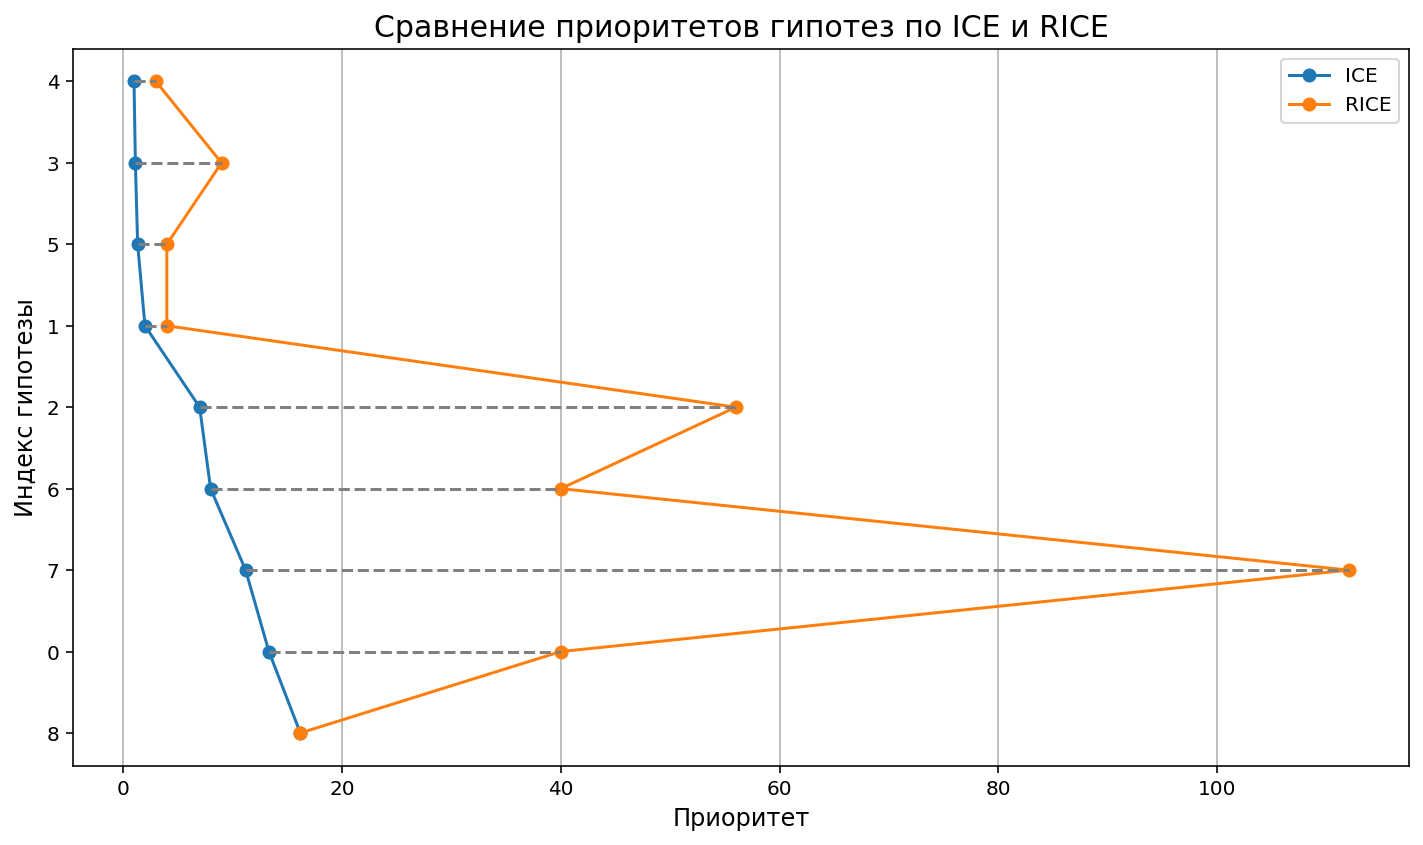

In [14]:
# Создаем список индексов гипотез
indices = range(len(priority_data))

# Получаем значения ICE и RICE
ice_values = priority_data['ICE'].values
rice_values = priority_data['RICE'].values

# Настраиваем график
plt.figure(figsize=(10, 6))

# Строим линии для ICE и RICE
plt.plot(ice_values, indices, marker='o', label='ICE')
plt.plot(rice_values, indices, marker='o', label='RICE')

# Добавляем горизонтальные линии для каждой гипотезы
for i in indices:
    plt.plot([ice_values[i], rice_values[i]], [i, i], color='grey', linestyle='--')

# Добавляем подписи
plt.yticks(indices, priority_data.index)  # Используем индексы из priority_data на оси Y
plt.xlabel('Приоритет', fontsize=12)
plt.ylabel('Индекс гипотезы', fontsize=12)
plt.title('Сравнение приоритетов гипотез по ICE и RICE', fontsize=15)
plt.legend()
plt.grid(axis='x')

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Показываем график
plt.tight_layout()
plt.show()

Согласно графику, видим, что только у `9-ой` гипотезы абсолютно равный приоритет. Меньше всего рознятся показатели приоритета у `2, 5, 6` гипотезы (смотрим не на индекс, а на номер гипотезы). Больше всего отличаюся приоритеты у `8,3,7 и 1` гипотезы.

**Теперь объясним, почему так произошло**

Применение фреймворка `ICE` для приоритизации гипотез осуществляется с применением параметра `impact`, а фреймворка `RICE` - с применением параметра `reach`. Поэтому в первом случае у нас оказались самыми приоритетными - гипотезы `9, 1, 8 и 7`, а во втором - `8, 3, 1, и 7`. 

Так произошло, потому что параметры `reach` и `impact` имеют существенные различия: первый отвечает за число пользователей, второй — за силу влияния изменения метрики на этих пользователей. Поэтому, по количеству пользователей приоритетны одни гипотезы, а по силе влияния на изменения метрики - другие. 

## Анализ A/B-теста
<a id='A_B_test_analysis'></a>

Аналитиком был проведен A/B-тест, получены результаты, отраженные в файлах `/datasets/orders.csv` и `/datasets/visitors.csv`. На основании имеющихся данных проанализируем некоторые А/В тесты.

### Анализ A/B-теста: построение графика кумулятивной выручки по группам. Формирование выводов и предположений

Построим графики кумулятивной выручки по группам. Сделаем выводы и предположения.

Для начала ообъединим две таблицы (из датафреймов `data_orders` и `data_visitors`) в одну с понятными названиями столбцов:

In [15]:
# создаем массив уникальных пар значений дат и групп теста
datesGroups = data_orders[['date','group']].drop_duplicates()

# получаем агрегированные кумулятивные по дням данные о заказах 
ordersAggregated = datesGroups.apply(lambda x: data_orders[np.logical_and(data_orders['date'] <= x['date'], data_orders['group'] == x['group'])].agg({'date' : 'max', 'group' : 'max', 'transaction_id' : 'nunique', 'visitor_id' : 'nunique', 'revenue' : 'sum'}), axis=1).sort_values(by=['date','group'])

# получаем агрегированные кумулятивные по дням данные о посетителях интернет-магазина 
visitorsAggregated = datesGroups.apply(lambda x: data_visitors[np.logical_and(data_visitors['date'] <= x['date'], data_visitors['group'] == x['group'])].agg({'date' : 'max', 'group' : 'max', 'visitors' : 'sum'}), axis=1).sort_values(by=['date','group'])

# объединяем кумулятивные данные в одной таблице и присваиваем ее столбцам понятные названия
cumulativeData = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

cumulativeData.head(5)

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,142779,719
1,2019-08-01,B,17,17,59758,713
2,2019-08-02,A,42,36,234381,1338
3,2019-08-02,B,40,39,221801,1294
4,2019-08-03,A,66,60,346854,1845


Теперь построим **график кумулятивной выручки по группам A/B-тестирования**:

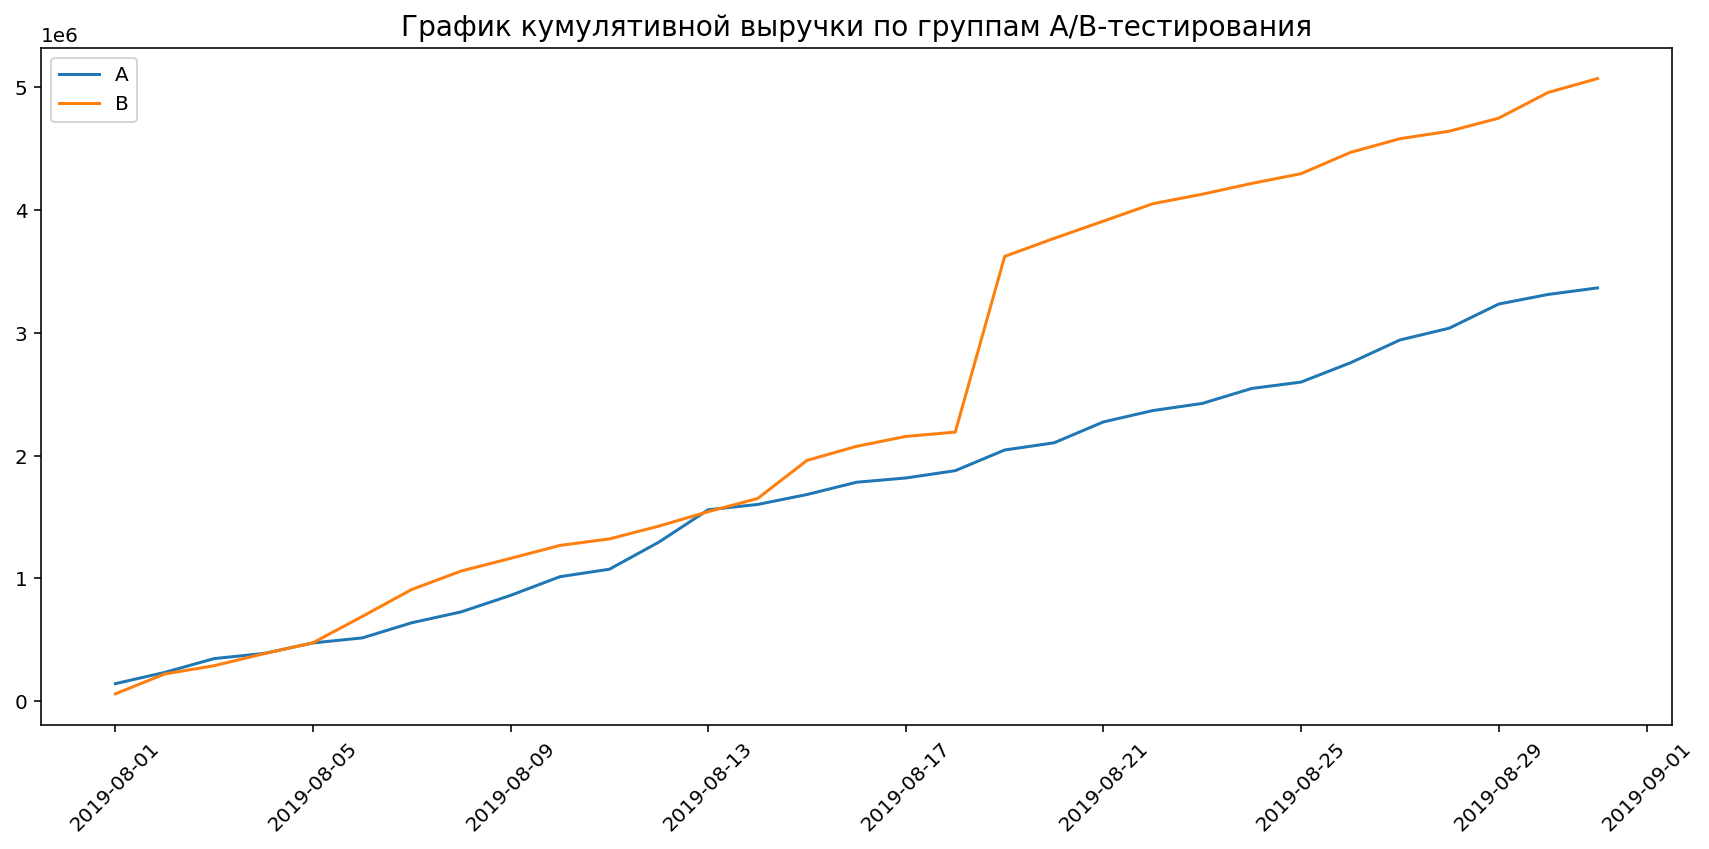

In [16]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

# Задаем размер графика
plt.figure(figsize=(12, 6))  

# Строим график выручки группы А
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')

# Строим график выручки группы B
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')

plt.legend()

# Добавляем заголовок графика
plt.title('График кумулятивной выручки по группам A/B-тестирования', fontsize=14)

# Поворачиваем названия по оси X на 45 градусов
plt.xticks(rotation=45)

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Показываем график
plt.tight_layout()
plt.show()

**Выручка обеих групп демонстрирует стабильный рост на протяжении всего теста**. 

Однако на графике у группы В наблюдаются резкий подъем в выручке, что может указывать на всплески числа заказов (середина августа - подготовка к учебе?) или появление крупных заказов, влияющих на итоговую сумму (о максимальной сумме заказа и сравнение ее с медианой уже шла речь при обзоре данных). Эти аномалии следует дополнительно изучить, чтобы лучше понять их причины и влияние на результаты A/B-теста.

### Анализ A/B-теста: построение графика кумулятивного среднего чека по группам. Формирование выводов и предположений

Построим графики среднего чека по группам — разделим кумулятивную выручку на кумулятивное число заказов: 

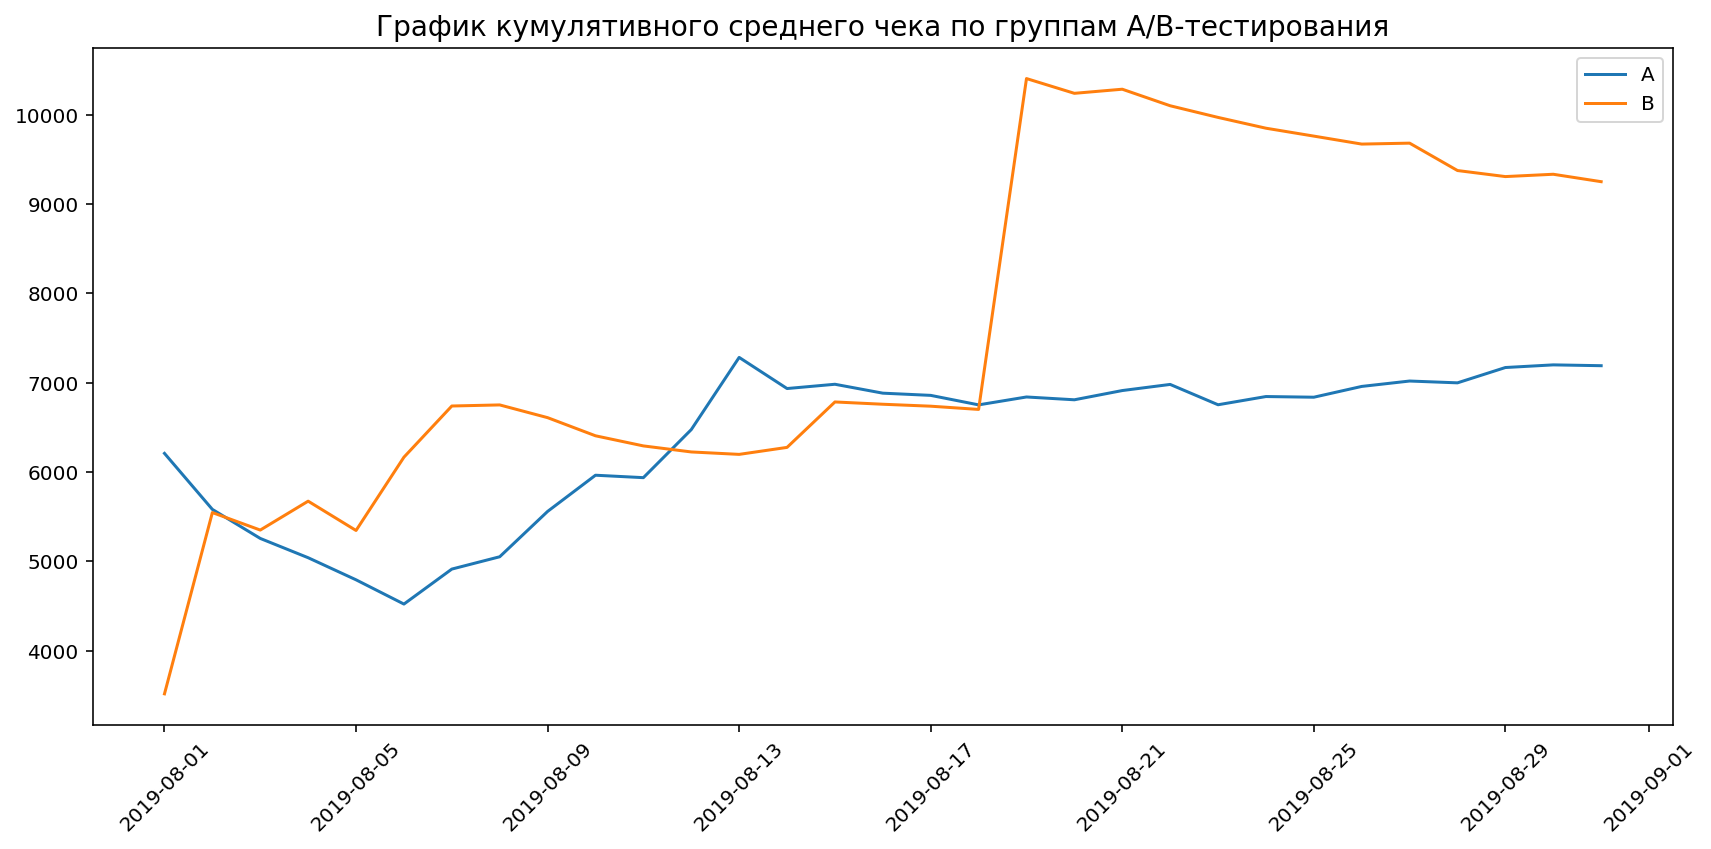

In [17]:
# Задаем размер графика
plt.figure(figsize=(12, 6))  

plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B')
plt.legend()

# Добавляем заголовок графика
plt.title('График кумулятивного среднего чека по группам A/B-тестирования', fontsize=14)

# Поворачиваем названия по оси X на 45 градусов
plt.xticks(rotation=45)

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Показываем график
plt.tight_layout()
plt.show()

**Средний чек по группам A и B показывает разные тенденции**. **В группе A** (синяя линия) наблюдаются заметные колебания, особенно в начале теста, что свидетельствует о высоком уровне изменчивости в поведении пользователей. Однако к концу теста средний чек выравнивается и достигает более стабильного уровня, указывая на то, что накопленные данные становятся более предсказуемыми.

**Группа B** (оранжевая линия) демонстрирует более стабильные значения среднего чека на протяжении всего теста, что говорит о меньшей изменчивости и более предсказуемом поведении пользователей в этой группе. Несмотря на резкие скачки (наличие крупной покупки?), общий тренд остается более равномерным.

В целом, **выравнивание среднего чека в обеих группах свидетельствует о том, что данные начинают стабилизироваться, и дальнейшие наблюдения помогут подтвердить или опровергнуть эти тренды**.

### Анализ A/B-теста: построение графика относительного изменения кумулятивного среднего чека группы B к группе A. Формирование выводов и предположений

Построим график относительного различия для среднего чека группы B к группе A. Добавим горизонтальную ось методом `axhline()`:

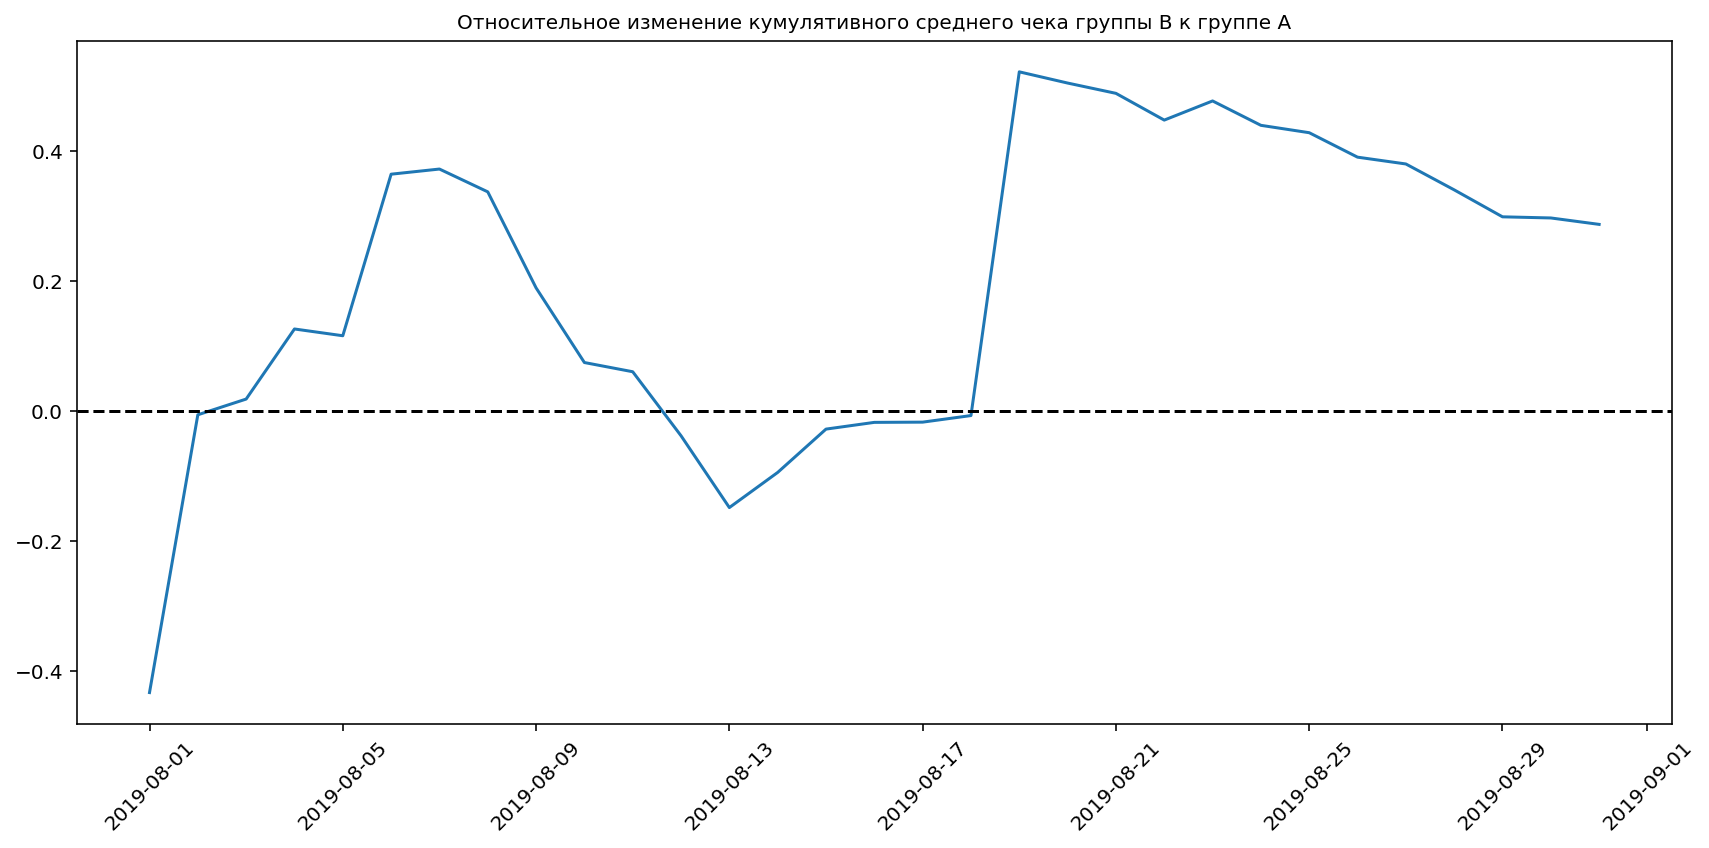

In [18]:
# собираем данные в одном датафрейме
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

# Задаем размер графика
plt.figure(figsize=(12, 6))  

# cтроим отношение средних чеков
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)

# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--')

# Добавляем заголовок графика
plt.title('Относительное изменение кумулятивного среднего чека группы B к группе A', fontsize=10)

# Поворачиваем названия по оси X на 45 градусов
plt.xticks(rotation=45)

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Показываем график
plt.tight_layout()
plt.show()

График показывает, что **средний чек группы B большую часть времени значительно превосходит средний чек группы A**, но также демонстрирует значительные колебания. Это может быть связано с аномальными данными или изменениями в поведении пользователей, такими как увеличение количества небольших заказов или возврат более дорогих товаров.

### Анализ A/B-теста: построение графика кумулятивного среднего количества заказов на посетителя по группам. Формирование выводов и предположений.

Аналогично проанализируем график кумулятивного среднего количества заказов на посетителя по группам. Зададим масштаб осей методом plt.axis(). 


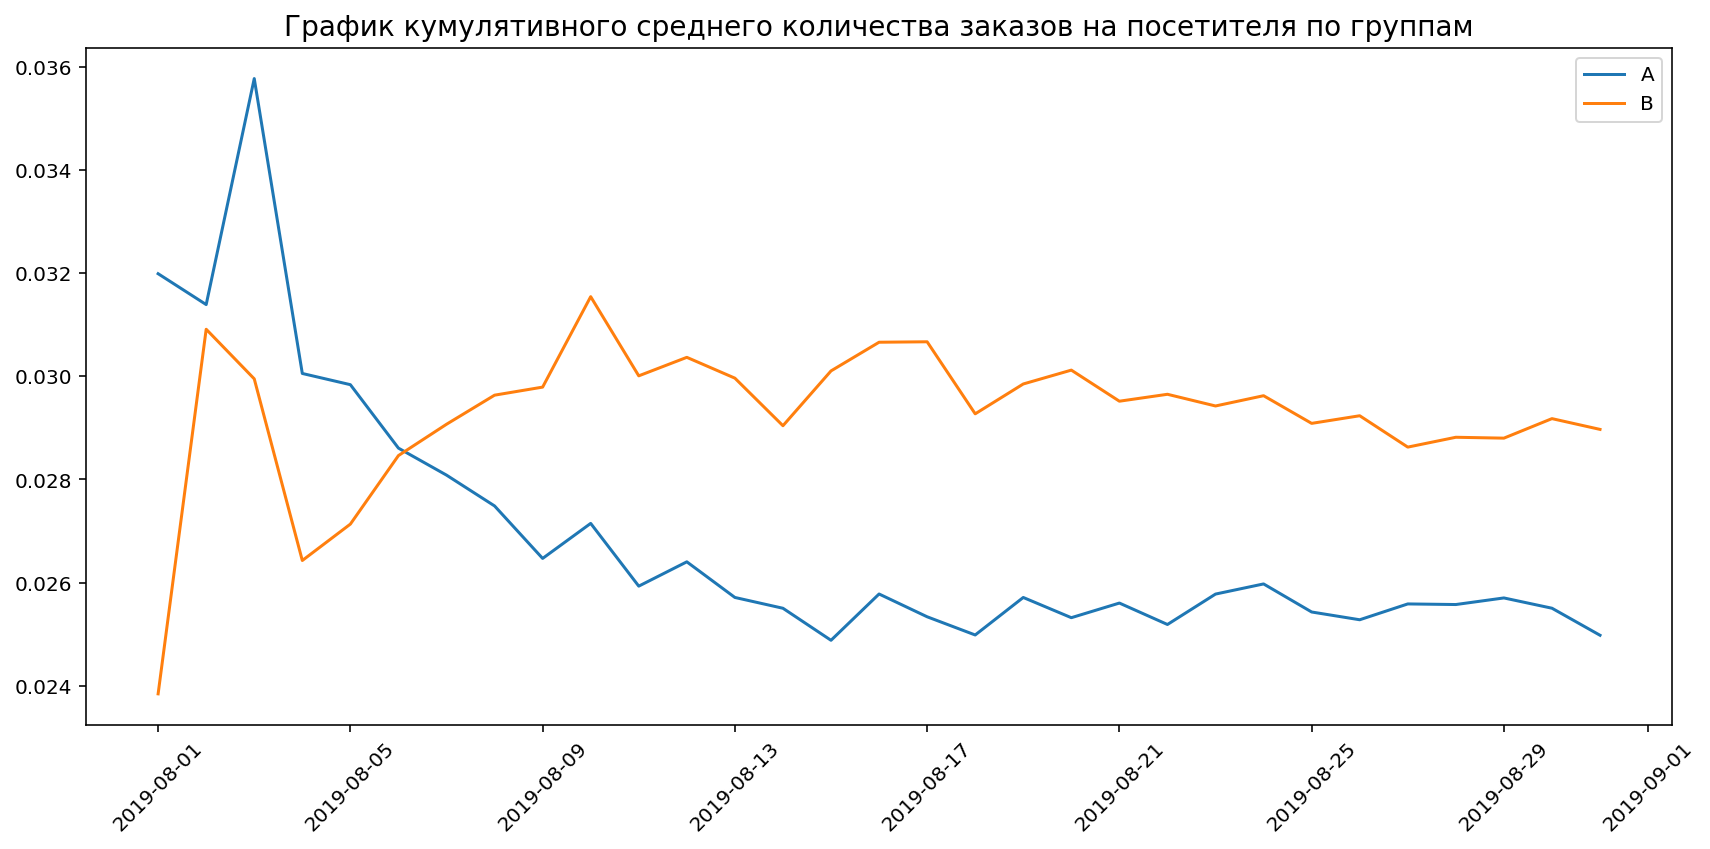

In [19]:
# считаем среднее количество заказов на посетителя
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

# отделяем данные по группе A
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']

# отделяем данные по группе B
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

# Задаем размер графика
plt.figure(figsize=(12, 6))  

# строим графики
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
plt.legend()

# Добавляем заголовок графика
plt.title('График кумулятивного среднего количества заказов на посетителя по группам', fontsize=14)

# Поворачиваем названия по оси X на 45 градусов
plt.xticks(rotation=45)

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Показываем график
plt.tight_layout()
plt.show()

На графике кумулятивного среднего количества заказов на посетителя группы A наблюдаются резкие колебания в начале теста, но с течением времени значения стабилизировались, указывая на предсказуемое поведение пользователей. В то же время группа B стартовала с более низких значений, но демонстрировала положительную динамику и более стабильные колебания. В результате **группа B достигла более высокого среднего количества заказов на посетителя по сравнению с группой A**, что указывает на эффективность стратегии в группе B.

### Анализ A/B-теста: построение графика относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Формирование выводов и предположений

Построим график изменения кумулятивного среднего количества заказов на посетителя группы B к группе A:

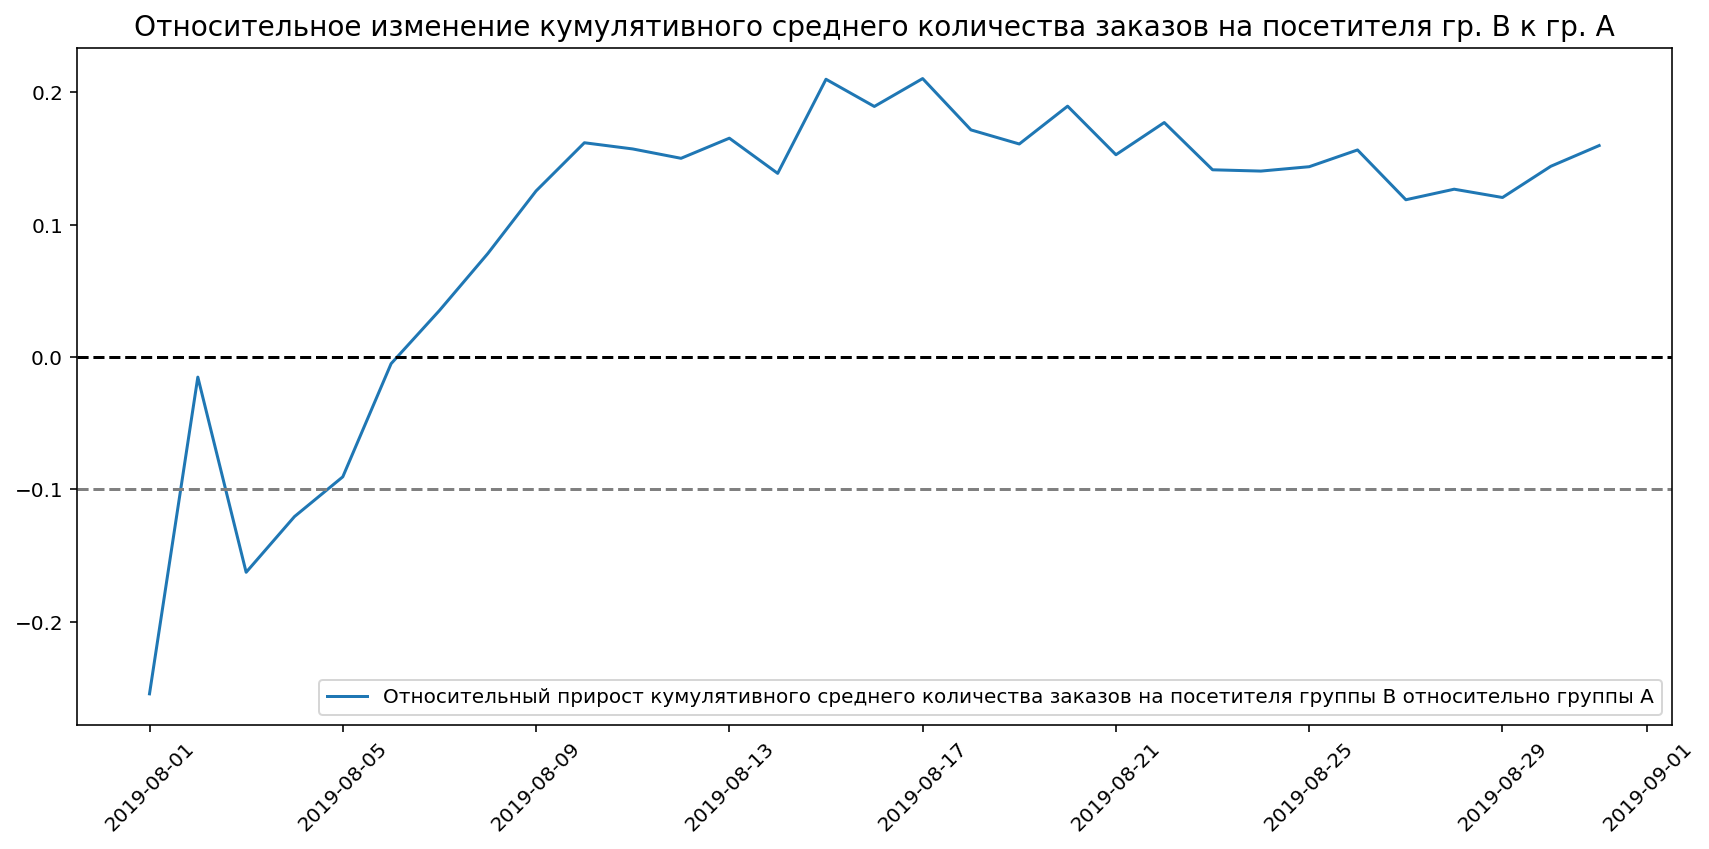

In [20]:
# Задаем размер графика
plt.figure(figsize=(12, 6))  

mergedCumulativeConversions = cumulativeDataA[['date','conversion']].merge(cumulativeDataB[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

plt.plot(mergedCumulativeConversions['date'], mergedCumulativeConversions['conversionB']/mergedCumulativeConversions['conversionA']-1, label="Относительный прирост кумулятивного среднего количества заказов на посетителя группы B относительно группы A")
plt.legend()

plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=-0.1, color='grey', linestyle='--')

# Добавляем заголовок графика
plt.title('Относительное изменение кумулятивного среднего количества заказов на посетителя гр. B к гр. A', fontsize=14)

# Поворачиваем названия по оси X на 45 градусов
plt.xticks(rotation=45)

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Показываем график
plt.tight_layout()
plt.show()

**В начале теста группа B значительно уступала группе A, но затем произошло резкое изменение, и группа B вырвалась вперёд**. После этого среднее количество заказов на посетителя для группы B начало колебаться, демонстрируя как рост, так и снижение. 

Сейчас отношение среднего количества заказов на посетителя для группы B к группе A ещё не установилось на стабильном уровне. Данные указывают на высокую вариативность, что затрудняет формирование окончательных выводов о тесте. Для более точного анализа потребуется рассмотреть возможные аномалии и выбросы, которые могут повлиять на результаты.

### Анализ A/B-теста: построение точечного графика количества заказов по пользователям. Формирование выводов и предположений

Помимо среднего чека, проанализируем и конверсию.

Пользователи, которые делают много заказов, оказывают влияние на числитель формулы конверсии. Вероятно, их поведение отличается от поведения среднестатистического пользователя. Если речь не идет о интернет-магазине с постоянным спросом, то **«обычный» пользователь за короткий период времени делает не более двух заказов**.

Для начала **подсчитаем количество заказов по пользователям** и посмотрим на результат:

In [21]:
ordersByUsers = (
    data_orders.groupby('visitor_id', as_index=False)
    .agg({'transaction_id': 'nunique'})
)

ordersByUsers.columns = ['user_id', 'orders']

ordersByUsers.sort_values(by='orders', ascending=False).head(10)

,user_id,orders
908,3967698036,3
55,249864742,3
478,2108163459,3
687,2988190573,3
890,3908431265,3
138,611059232,3
632,2742574263,3
157,678354126,2
323,1404560065,2
452,1985475298,2


Есть пользователи, которые совершали **5, 8, 9 и 11 заказов**.

Значительно больше, чем обычный пользователь за неделю.

Построим **гистрограмму распределения количества заказов на одного пользователя**.

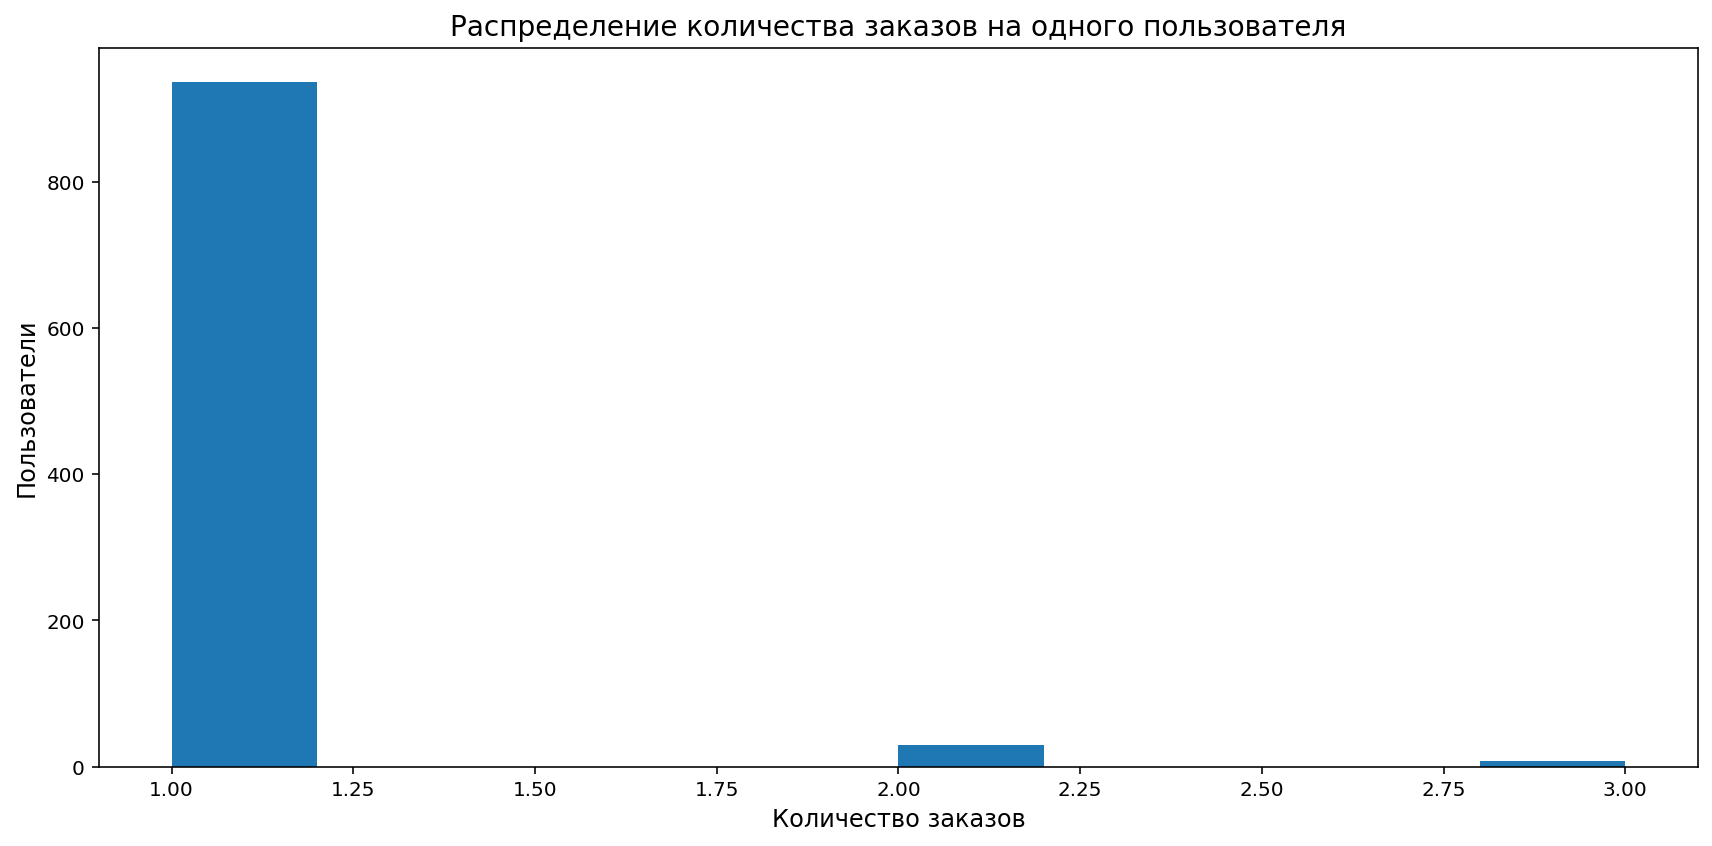

In [22]:
# Задаем размер графика
plt.figure(figsize=(12, 6))  

plt.hist(ordersByUsers['orders'])

# Добавляем заголовок графика
plt.title('Распределение количества заказов на одного пользователя', fontsize=14)

# Подписываем оси
plt.xlabel('Количество заказов', fontsize=12)  
plt.ylabel('Пользователи', fontsize=12)  

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

plt.tight_layout()
plt.show()

**Основная часть покупателей сделала только один заказ**, но также присутствует **доля пользователей, которые оформили от двух до трех заказов.**

Построим теперь **точечную диаграмму числа заказов на одного пользователя**:

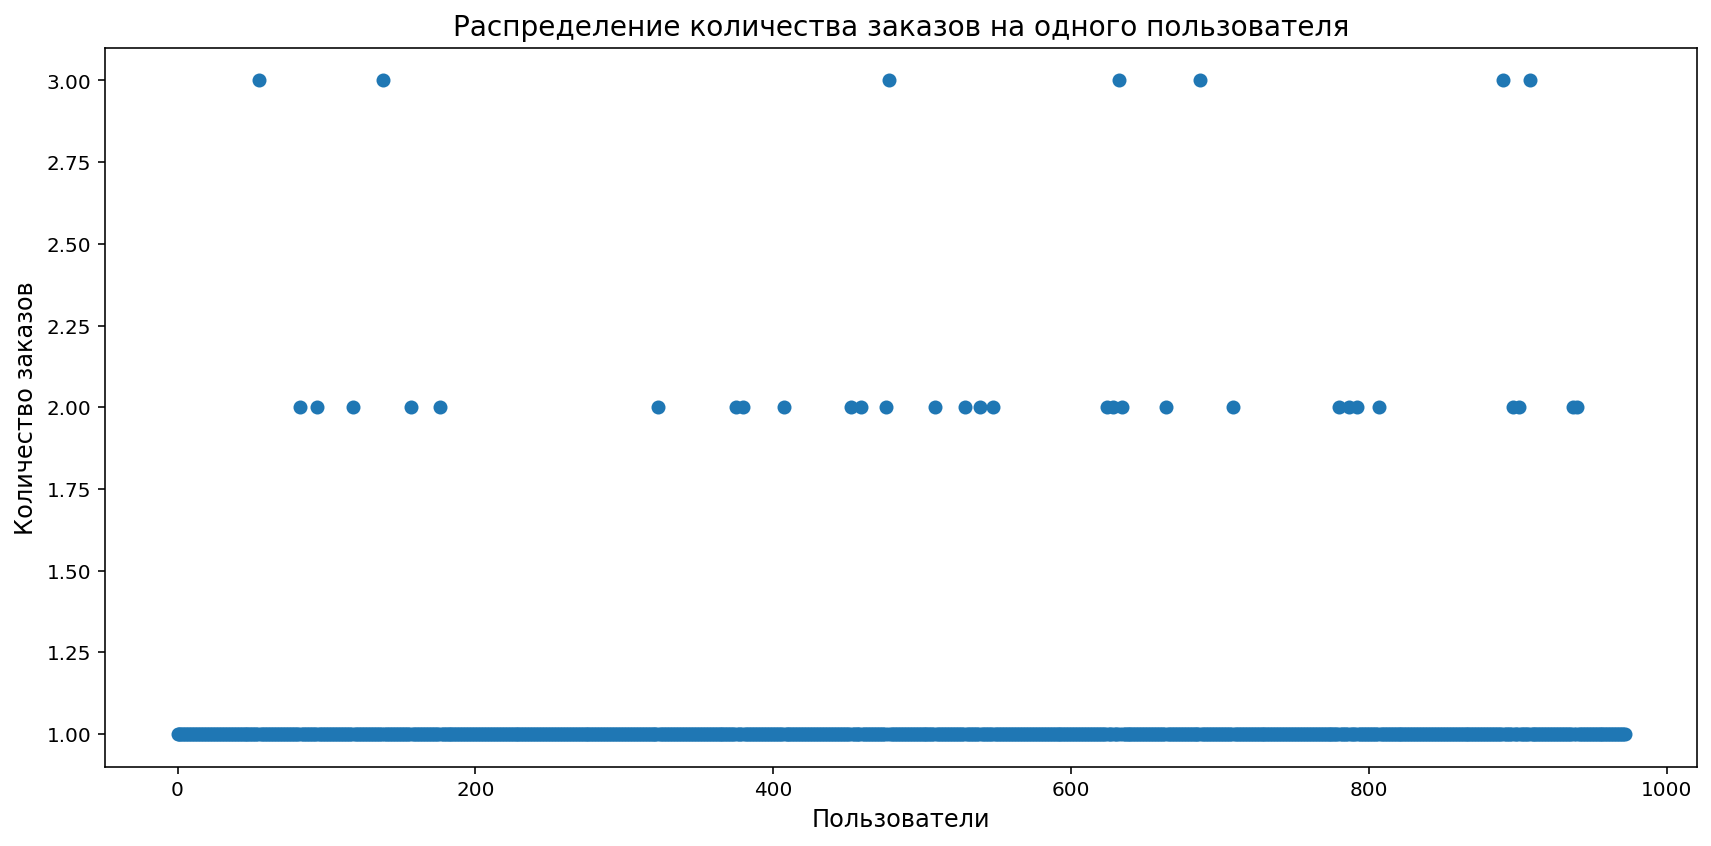

In [23]:
x_values = pd.Series(range(0,len(ordersByUsers)))

# Задаем размер графика
plt.figure(figsize=(12, 6))  

plt.scatter(x_values, ordersByUsers['orders'])

# Добавляем заголовок графика
plt.title('Распределение количества заказов на одного пользователя', fontsize=14)

# Подписываем оси
plt.xlabel('Пользователи', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)  

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

plt.tight_layout()
plt.show()

Выводы подтверждаются: **абсолютное большинство пользователей оформили по 1 заказу, но имеется так же много пользователей с 2 заказами  и совсем чуть-чуть с тремя**. Точная доля этих пользователей с тремя заказами остается неясной — не понятно, следует ли их считать аномалиями.

### Анализ A/B-теста: расчет 95-й и 99-й перцентили количества заказов на пользователя. Выбор границы для определения аномальных пользователей

Посчитаем выборочные перцентили (95-й и 99-й) количества заказов на одного пользователя:

In [24]:
print(np.percentile(ordersByUsers['orders'], [95, 99]))

[1. 2.]


**Не более `5%` пользователей оформляли больше чем `1` заказ. И только `1%` пользователей заказывали более `двух` раз**.

Разумно **выбрать `2` заказа** на одного пользователя за верхнюю границу числа заказов, и отсеять остальных аномальных пользователей по ней.

### Анализ A/B-теста: построение точечного графика стоимостей заказов. Формирование выводов и предположений

Построим и изучим для начала **гистограмму распределения стоимостей заказов**:

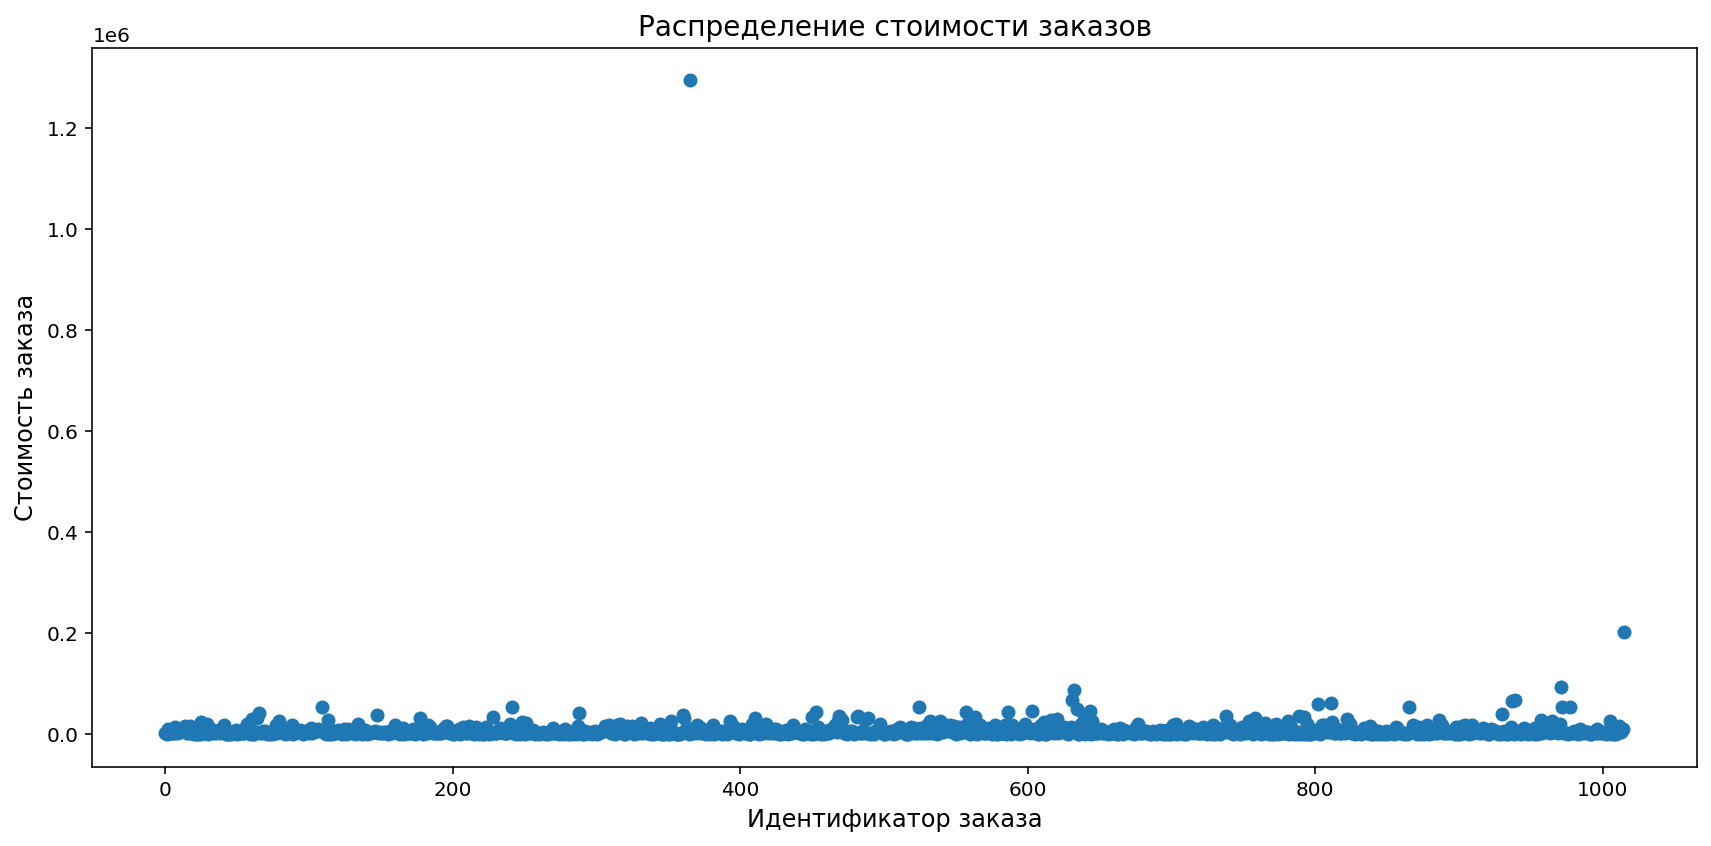

In [25]:
plt.figure(figsize=(12, 6))

x_values = pd.Series(range(0,len(data_orders['revenue'])))
plt.scatter(x_values, data_orders['revenue'])

# Добавляем заголовок графика
plt.title('Распределение стоимости заказов', fontsize=14)

# Подписываем оси
plt.xlabel('Идентификатор заказа', fontsize=12) 
plt.ylabel('Стоимость заказа', fontsize=12)  

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

plt.tight_layout()
plt.show()

Всё, как предполагалось: есть немного дорогих заказов. Особо выбивающиеся из общей картины: заказы на сумму около 200 тыс. руб. и 1 290 000 руб. 

Большая часть заказов находится в диапазоне до 10 000 руб. По графику можно выбрать границу аномальных заказов между 60 000 рублей и выше. Однако принято отсеивать от 1% до 5% наблюдений с крайними значениями.

### Анализ A/B-теста: расчет 95-й и 99-й перцентили стоимости заказов. Выбор границы для определения аномальных заказов

Определим 95-й и 99-й перцентили стоимости заказа в выборке:

In [26]:
print(np.percentile(data_orders['revenue'], [95, 99]))

[26785. 53904.]


**Не более `5%` заказов дороже `26 785` рублей и не более `1%` дороже `53 904` рублей.**

Здесь разумно выбрать 27 000 руб. на одного пользователя за верхнюю границу числа заказов, и отсеять аномальных пользователей по ней.

### Анализ A/B-теста: расчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Формирование выводов и предположений

Посчитаем статистическую значимость различий в среднем числе заказов на пользователя между группами по «сырым» данным — без удаления аномальных пользователей.

Сформулируем гипотезы:
- `Н0:` Нет различий в среднем количестве заказов между группами
- `Н1:` Есть различия в среднем количестве заказов между группами

Начнём с подготовки данных.

In [27]:
# Выбираем данные о количестве пользователей в указанную дату по группе A и переименовываем столбцы
visitorsADaily = data_visitors[data_visitors['group'] == 'A'][['date', 'visitors']]
visitorsADaily.columns = ['date', 'visitorsPerDateA']

# Создаем кумулятивное количество пользователей для группы A
visitorsACummulative = visitorsADaily.apply(
    lambda x: visitorsADaily[visitorsADaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateA': 'sum'}
    ),
    axis=1,
)
visitorsACummulative.columns = ['date', 'visitorsCummulativeA']

# Выбираем данные о количестве пользователей в указанную дату по группе B и переименовываем столбцы
visitorsBDaily = data_visitors[data_visitors['group'] == 'B'][['date', 'visitors']]
visitorsBDaily.columns = ['date', 'visitorsPerDateB']

# Создаем кумулятивное количество пользователей для группы B
visitorsBCummulative = visitorsBDaily.apply(
    lambda x: visitorsBDaily[visitorsBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateB': 'sum'}
    ),
    axis=1,
)
visitorsBCummulative.columns = ['date', 'visitorsCummulativeB']

# Группируем заказы группы A по дате, подсчитывая уникальное количество заказов и суммарную выручку
ordersADaily = (
    data_orders[data_orders['group'] == 'A'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
)
ordersADaily.columns = ['date', 'ordersPerDateA', 'revenuePerDateA']

# Создаем кумулятивные значения количества заказов и выручки для группы A
ordersACummulative = ordersADaily.apply(
    lambda x: ordersADaily[ordersADaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateA': 'sum', 'revenuePerDateA': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
ordersACummulative.columns = [
    'date',
    'ordersCummulativeA',
    'revenueCummulativeA',
]

# Группируем заказы группы B по дате, подсчитывая  уникальное количество заказов  и суммарную выручку
ordersBDaily = (
    data_orders[data_orders['group'] == 'B'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
)
ordersBDaily.columns = ['date', 'ordersPerDateB', 'revenuePerDateB']

# Создаем кумулятивные значения количества заказов и выручки для группы B
ordersBCummulative = ordersBDaily.apply(
    lambda x: ordersBDaily[ordersBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateB': 'sum', 'revenuePerDateB': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
ordersBCummulative.columns = [
    'date',
    'ordersCummulativeB',
    'revenueCummulativeB',
]

# Объединяем все полученные данные в один датафрейм
data = (
    ordersADaily.merge(
        ordersBDaily, left_on='date', right_on='date', how='left'
    )
    .merge(ordersACummulative, left_on='date', right_on='date', how='left')
    .merge(ordersBCummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsADaily, left_on='date', right_on='date', how='left')
    .merge(visitorsBDaily, left_on='date', right_on='date', how='left')
    .merge(visitorsACummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsBCummulative, left_on='date', right_on='date', how='left')
)

# Выводим первые 5 строк объединенного датафрейма для проверки
data.head(5)

,date,ordersPerDateA,revenuePerDateA,ordersPerDateB,revenuePerDateB,ordersCummulativeA,revenueCummulativeA,ordersCummulativeB,revenueCummulativeB,visitorsPerDateA,visitorsPerDateB,visitorsCummulativeA,visitorsCummulativeB
0,2019-08-01,23,142779,17,59758,23,142779,17,59758,719,713,719,713
1,2019-08-02,19,91602,23,162043,42,234381,40,221801,619,581,1338,1294
2,2019-08-03,24,112473,14,67049,66,346854,54,288850,507,509,1845,1803
3,2019-08-04,11,41176,14,96890,77,388030,68,385740,717,770,2562,2573
4,2019-08-05,22,86383,21,89908,99,474413,89,475648,756,707,3318,3280


Напомним названия столбцов данных:
- `date` — дата;
- `ordersPerDateA` — количество заказов в выбранную дату в группе A;
- `revenuePerDateA` — суммарная выручка в выбранную дату в группе A;
- `ordersPerDateB` — количество заказов в выбранную дату в группе B;
- `revenuePerDateB` — суммарная выручка в выбранную дату в группе B;
- `ordersCummulativeA` — суммарное число заказов до выбранной даты включительно в группе A;
- `revenueCummulativeA` — суммарная выручка до выбранной даты включительно в группе A;
- `ordersCummulativeB` — суммарное количество заказов до выбранной даты включительно в группе B;
- `revenueCummulativeB` — суммарная выручка до выбранной даты включительно в группе B;
- `visitorsPerDateA` — количество пользователей в выбранную дату в группе A;
- `visitorsPerDateB` — количество пользователей в выбранную дату в группе B;
- `visitorsCummulativeA` — количество пользователей до выбранной даты включительно в группе A;
- `visitorsCummulativeB` — количество пользователей до выбранной даты включительно в группе B.

Теперь посчитаем статистическую значимость различия в среднем количестве заказов между группами. Создадим переменные `ordersByUsersA` и `ordersByUsersB` со столбцами `['user_id', 'orders']`. В них для пользователей, которые заказывали хотя бы 1 раз, укажем число совершённых заказов.

In [28]:
# Создадим переменную ordersByUsersA со столбцами ['user_id', 'orders']
ordersByUsersA = (
    data_orders[data_orders['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)

# Переименуем столбцы
ordersByUsersA.columns = ['user_id', 'orders']

# Создадим переменную ordersByUsersB со столбцами ['user_id', 'orders']
ordersByUsersB = (
    data_orders[data_orders['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)

# Переименуем столбцы
ordersByUsersB.columns = ['user_id', 'orders']

Объявим переменные `sampleA` и `sampleB`, в которых пользователям из разных групп будет соответствовать количество заказов. Тем, кто ничего не заказал, будут соответствовать нули. Это нужно, чтобы подготовить выборки к проверке критерием Манна-Уитни.

In [29]:
# Объявим переменные sampleA и sampleB, в которых пользователям из разных групп будет соответствовать количество заказов
sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)
sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(data['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0)

# Расчет p-value для теста Манна-Уитни
p_value = stats.mannwhitneyu(sampleA, sampleB)[1]

# Расчет относительного изменения среднего числа заказов между группами
relative_change = (sampleB.mean() / sampleA.mean() - 1)

# Вывод 
print("p-value: {0:.3f}".format(p_value))
print("Относительное изменение среднего числа заказов группы B относительно группы A: {0:.3f}".format(relative_change))

p-value: 0.011
Относительное изменение среднего числа заказов группы B относительно группы A: 0.160


Вывод: **По «сырым» данным выявлены различия в среднем числе заказов между группами A и B**.

Первое значение — `p-value` = `0.011`, что значительно меньше 0.05. Это позволяет **отвергнуть нулевую гипотезу, утверждающую, что между группами нет статистически значимых различий**. Второе значение показывает, что `относительный прирост среднего числа заказов группы B составляет 16%`.

Однако, важно также учитывать возможные внешние факторы, которые могли повлиять на результаты, такие как сезонность или другие акции, проходившие одновременно. Поэтому дальнейший анализ, включая изучение аномальных пользователей и заказов, будет полезен для более точного понимания полученных результатов и их устойчивости.

### Анализ A/B-теста:  расчет статистической значимости различий в среднем чеке заказа между группами по «сырым» данным. Формирование выводов и предположений

Теперь проверим статистическую значимость различий в среднем чеке между сегментами. 
- `Н0`: Нет различий в среднем чеке между группами
- `Н1`: Есть различия в среднем чеке между группами

Чтобы рассчитать статистическую значимость различий в среднем чеке, передадим критерию `mannwhitneyu()` данные о выручке с заказов.

Найдём **относительные различия в среднем чеке между группами**:

In [30]:
print('p-value:')
print('{0:.3f}'.format(stats.mannwhitneyu(data_orders[data_orders['group']=='A']['revenue'], data_orders[data_orders['group']=='B']['revenue'])[1]))
print('Относительное изменение в среднем чеке группы B относительно группы A:')
print('{0:.3f}'.format(data_orders[data_orders['group']=='B']['revenue'].mean()/data_orders[data_orders['group']=='A']['revenue'].mean()-1))

p-value:
0.829
Относительное изменение в среднем чеке группы B относительно группы A:
0.287


**P-value (`0.829`) значительно больше `0.05`.** Это означает, что **нет оснований отвергать нулевую гипотезу** и утверждать, что в среднем чеке есть статистически значимые различия между группами A и B.

Тем не менее, **наблюдаемое различие в среднем чеке, составившее `28.7%` в пользу группы B, свидетельствует о том, что хотя различия и не являются статистически значимыми, группа B все же демонстрирует более высокий средний чек по сравнению с группой A.** 

### Анализ A/B-теста: расчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Формирование выводов и предположений

Выше было установлено, установили, что `95-й` и `99-й` перцентили средних чеков составляют `28 000` и  `58 233.2 рублей` соответственно. Также `95-й` и `99-й` перцентили по количеству заказов на пользователя равны `2` и `4`.

Мы определим **аномальных пользователей как тех, кто сделал `более 2 заказов` или совершил хотя бы один заказ на сумму `свыше 30 000 рублей`**. Таким образом, мы исключим 5% пользователей с наибольшим количеством заказов и от 1% до 5% пользователей с дорогими заказами.

Сначала выделим пользователей, которые сделали больше 2 заказов, в переменной `usersWithManyOrders`, и пользователей, совершивших заказы дороже 27 000 рублей, в переменной `usersWithExpensiveOrders`. Затем объединим их в таблице `abnormalUsers`.

Наконец, мы узнаем общее количество аномальных пользователей, используя атрибут `shape`.

In [31]:
# Выделим пользователей, которые сделали больше 2 заказов, в переменной usersWithManyOrders
orders_lim = 2

usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['orders'] > orders_lim]['user_id'],
        ordersByUsersB[ordersByUsersB['orders'] > orders_lim]['user_id'],
    ],
    axis=0,
)

# Выделим пользователей, совершивших заказы дороже 27 000 рублей, в переменной usersWithExpensiveOrders
revenue_lim = 27000

usersWithExpensiveOrders = data_orders[data_orders['revenue'] > revenue_lim]['visitor_id']
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)
print(abnormalUsers.head(5))
print('-' * 35)
print('Всего аномальных пользователей:', abnormalUsers.shape[0])

568     113298937
1099    148427295
928     204675465
33      249864742
684     358944393
dtype: int64
-----------------------------------
Всего аномальных пользователей: 58


Всего 58 аномальных пользователей.

Узнаем, как их действия повлияли на результаты теста. Посчитаем **статистическую значимость различий в среднем количестве заказов между группами теста по очищенным данным**.

In [32]:
# Подготовка выборки количества заказов по пользователям по группам теста:
sampleAFiltered = pd.concat(
    [
        ordersByUsersA[
            np.logical_not(ordersByUsersA['user_id'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sampleBFiltered = pd.concat(
    [
        ordersByUsersB[
            np.logical_not(ordersByUsersB['user_id'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

# Применение статистический критерий Манна-Уитни к полученным выборкам:
print('p-value по очищенным данным:')
print('{0:.3f}'.format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
print('Относительное изменение среднего числа заказов группы B относительно группы A по очищенным данным:')
print('{0:.3f}'.format(sampleBFiltered.mean()/sampleAFiltered.mean()-1))

p-value по очищенным данным:
0.012
Относительное изменение среднего числа заказов группы B относительно группы A по очищенным данным:
0.182


По "сырым" данным мы получили результат p-value `0.011` и относительное изменение среднего числа заказов группы B относительно группы A - `0.182`. После отсечения аномальных заказов общая ситуация координально не изменилась, `p-value = 0.012`, что так же значительно меньше `0.05` и **позволяет отвергнуть нулевую гипотезу, утверждающую, что между группами нет статистически значимых различий**.  

Относительный прирост среднего числа заказов группы B увеличился на `2,2%` и стал равен `18,2%`.

### Анализ A/B-теста: расчет статистической значимости различий в среднем чеке заказа между группами по «очищенным» данным. Формирование выводов и предположений

Теперь посмотрим, произошло ли что-нибудь с результатами по среднему чеку.

In [33]:
print('p-value по очищенным данным:')
print(
    '{0:.3f}'.format(
        stats.mannwhitneyu(
            data_orders[
                np.logical_and(
                    data_orders['group'] == 'A',
                    np.logical_not(data_orders['visitor_id'].isin(abnormalUsers)),
                )
            ]['revenue'],
            data_orders[
                np.logical_and(
                    data_orders['group'] == 'B',
                    np.logical_not(data_orders['visitor_id'].isin(abnormalUsers)),
                )
            ]['revenue'],
        )[1]
    )
)

print('Относительное изменение по среднему чеку группы B относительно группы A по очищенным данным:')
print(
    "{0:.3f}".format(
        data_orders[
            np.logical_and(
                data_orders['group'] == 'B',
                np.logical_not(data_orders['visitor_id'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        / data_orders[
            np.logical_and(
                data_orders['group'] == 'A',
                np.logical_not(data_orders['visitor_id'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        - 1
    )
)

p-value по очищенным данным:
0.646
Относительное изменение по среднему чеку группы B относительно группы A по очищенным данным:
-0.048


`P-value` снизился на целых `18.3%` и стал равен 0.646, однако его значение и здесь значительно больше 0.05. **После удаления аномальных значений также нет оснований отвергать нулевую гипотезу** и невозможно заявить, что в среднем чеке наблюдаются статистически значимые различия между группами A и B.

Тем не менее, разница между сегментами значительно изменилась: изначально средний чек группы B существенно превышал средний чек группы A (на `28.7%`), сейчас же, наоборот, средний чек группы A выше среднего чека группы B на `4.8%`. Это свидетельствует о том, что, несмотря на отсутствие статистической значимости, группа A теперь показывает лучший результат и более точные данные (после исключения аномалий) отражают реальное поведение пользователей и их предпочтения.

## Принятие решения по результатам теста и его объяснение

Чтобы принять решение по результатам теста, сначала нужно **аккумулировать все имеющиеся факты**:

1. **Есть статистически значимое различие по среднему количеству заказов** между группами как по «сырым», так и по данным после фильтрации аномалий;
2. **Нет статистически значимого различия по среднему чеку** между группами  как по «сырым», так и по данным после фильтрации аномалий;
3. **График различия среднего количества заказов между группами сообщает, что результаты группы B в своем большинстве лучше группы A и нет значительной тенденции к улучшению группы А.** В отношении среднего количества заказов на посетителя для группы B к группе A в последней трети эксперимента наблюдается стабилизация результатов: 

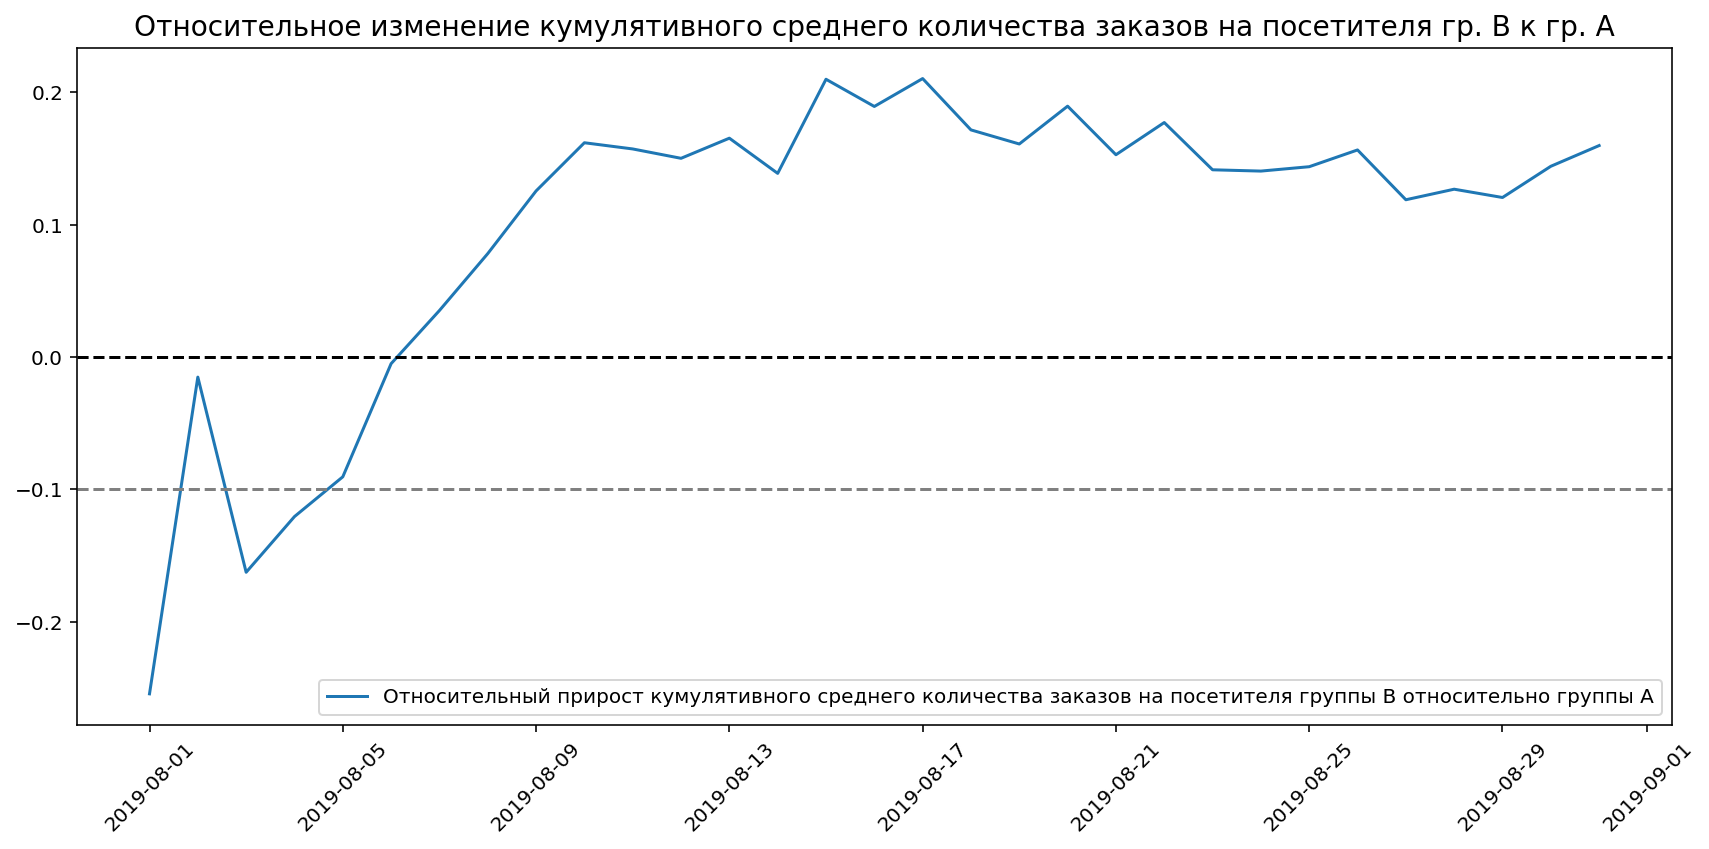

4. **График различия среднего чека говорит о том, что средний чек группы B большую часть времени значительно превосходит средний чек группы A**, но демонстрирует значительные колебания:

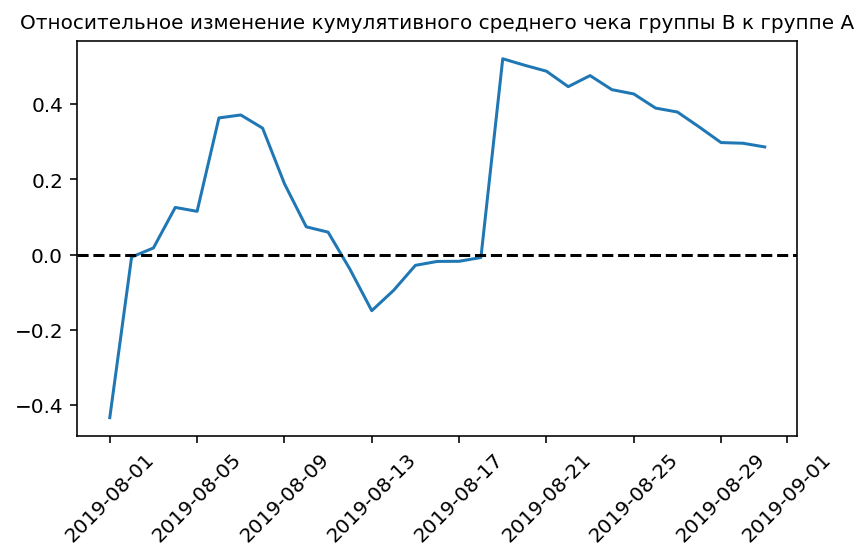

На основе проведенного анализа данных можно сделать вывод, что **тест следует остановить и зафиксировать победу группы B**. Несмотря на наличие значительной вариации в данных, статистически значимое различие в среднем количестве заказов между группами подтверждает, что пользователи группы B ведут себя активнее. И хоть различия в среднем чеке отсутсвуют и после фильтрации аномалий, первоначальные результаты указывают на преимущество группы B. 
